#   Forecasting de Demanda Eléctrica en España
## Análisis de Series Temporales con Machine Learning y Variables Meteorológicas

---

###   Descripción del Proyecto

Este proyecto tiene como objetivo **predecir la demanda eléctrica en España** utilizando modelos estadísticos (SARIMA) y modelos de Machine Learning, incorporando **variables meteorológicas y energéticas** como factores explicativos clave.

**Dataset:** [Energy Consumption, Generation, Prices and Weather - Spain (Kaggle)](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)

**Contexto:**
Según un paper de 2019, el forecasting en mercados energéticos es una de las áreas de mayor impacto del Machine/Deep Learning para la transición hacia una infraestructura eléctrica basada en renovables.

**Contenido del dataset:**
- **4 años de datos horarios** (2015-2018) 
- Consumo eléctrico real y forecast del TSO
- **Generación por fuente**: solar, eólica, gas, carbón, nuclear, hidráulica
- **Precios spot** y day-ahead
- **Datos meteorológicos** de las 5 ciudades más grandes de España:
  - Madrid, Barcelona, Valencia, Sevilla, Bilbao
  - Variables: temperatura, presión, humedad, velocidad del viento

**Fuentes:**
- ENTSOE (European Network of Transmission System Operators)
- Red Eléctrica de España (REE)
- Open Weather API

---

###   Objetivos Principales

1. **Limpieza y preparación** de datos con tratamiento correcto de valores nulos
2. **Análisis meteorológico**: Demostrar la relación entre clima y demanda eléctrica
3. **Feature Engineering avanzado**: Variables temporales, lags, rolling stats, y **weather features**
4. **Modelado estadístico**: SARIMA con análisis de tendencia, estacionalidad y residuo
5. **Machine Learning**: Random Forest y Gradient Boosting
6. **Análisis técnico**: Medias móviles, Golden Cross y volatilidad
7. **Comparación de modelos** y análisis de feature importance

**Hipótesis clave:**
> Las **variables meteorológicas** (especialmente temperatura) son factores explicativos fundamentales para la demanda eléctrica, junto con la información temporal (lags y estacionalidad).

---

###   Equipo de Trabajo y Responsabilidades

####   **Persona 1: Preparación de Datos y EDA**

**Tareas:**
-   Carga y exploración inicial del dataset
-   Conversión a series temporales (índice datetime)
-   Análisis de valores nulos y estrategia de imputación
-   Análisis exploratorio de demanda eléctrica
-   Análisis meteorológico: correlación clima-demanda
-   Visualizaciones de patrones diarios/semanales/estacionales

**Entregables:**
- Dataset limpio y correctamente indexado
- Informe de calidad de datos
- Gráficos exploratorios de demanda y temperatura

---

####   **Persona 2: Análisis Temporal y Comparación de Modelos**

**Tareas:**

-   **Lags**: 1h, 24h, 168h (capturar autocorrelación)
-   **Descomposición temporal**: tendencia, estacionalidad (period=24), residuo
-   **Test de estacionariedad** (ADF)
-	**ACF**
-   **Modelo SARIMA**: determinación de órdenes (p,d,q)(P,D,Q,s)
-   **Media móvil y Golden Cross** para precios eléctricos
-   **Análisis de volatilidad**

**Entregables:**
- Modelo SARIMA con parámetros justificados
- Análisis de cruces de medias móviles en precios
- Demostración de que temperatura y lags son cruciales

---

####   **Persona 3: Machine Learning**

**Tareas:**
-   **Modelos ML**: Random Forest y Gradient Boosting
-   **Feature importance**: identificar variables más predictivas
-   **Comparación final de modelos**: SARIMA vs RF vs GB
-   Visualizaciones de predicciones vs valores reales

**Entregables:**
- Modelos ML con hiperparámetros optimizados
- Análisis de feature importance
- Tabla comparativa de métricas (RMSE, MAE, MAPE)
- Conclusiones sobre mejor modelo y variables importantes

---

###   Preguntas de Investigación

1. **¿Qué ciudades/mediciones meteorológicas influyen más en la demanda eléctrica?**
2. **¿Podemos predecir 24 horas adelante mejor que el TSO?**
3. **¿Cuál es la relación entre temperatura y demanda?** (hipótesis: forma de U)
4. **¿Qué features son más importantes**: lags, temperatura, hora del día, generación?
5. **¿Qué modelo funciona mejor**: SARIMA, RF o Gradient Boosting?

---

---

##   1. Importación de Librerías

Importamos todas las librerías necesarias para el análisis completo.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---

##   2. Carga y Exploración Inicial del Dataset



In [45]:
# 1. Cargar dataset de energía
df_energy = pd.read_csv('./data/energy_dataset.csv')
print(f"Energy dataset: {df_energy.shape[0]:,} filas × {df_energy.shape[1]} columnas")

# 2. Cargar dataset de clima 
df_weather = pd.read_csv('./data/weather_features.csv')
print(f"Weather dataset: {df_weather.shape[0]:,} filas × {df_weather.shape[1]} columnas")

print("\n" + "=" * 80)
print("ESTRUCTURA DE LOS DATASETS:")
print("=" * 80)

print("\nEnergy Dataset:")
print(df_energy.info())

print("\nWeather Dataset:")
print(df_weather.info())


Energy dataset: 35,064 filas × 29 columnas
Weather dataset: 178,396 filas × 17 columnas

ESTRUCTURA DE LOS DATASETS:

Energy Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  str    
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat 

---

## 2b. Separación de Columnas de Forecast (Comparación con TSO)

### Objetivo Principal

El propósito de este notebook es **desarrollar nuestro propio pronóstico de demanda eléctrica** utilizando modelos estadísticos (SARIMA) y Machine Learning. Las columnas de forecast del TSO las utilizaremos como **referencia de comparación** para comparar nuestra previsión con la oficial de red electrica.

### Posible Data Leakage

Las columnas de **forecast del TSO** (pronóstico oficial del operador del sistema) representan una **potencial fuente de data leakage**:

- Si usamos estas columnas para entrenar nuestro modelo, estaríamos utilizando información que **no estaría disponible en un escenario real de predicción en tiempo real**.
- Esto podría inflar artificialmente la precisión de nuestro modelo.

### Estrategia: Separar para Comparación Limpia

**Acción:** Extraer columnas de forecast a dataset separado **ANTES del merge**, para:
1. ✓ Entrenar nuestros modelos **sin estas columnas** (pronóstico limpio)
2. ✓ **Comparar nuestras predicciones** con el pronóstico oficial del TSO
3. ✓ Responder: **¿Predecimos mejor o peor que el TSO?**

In [46]:
# Identificar y separar columnas de forecast (TSO) antes del merge
forecast_cols = [col for col in df_energy.columns if 'forecast' in col.lower() or 'ahead' in col.lower()]

print(f"Columnas de forecast encontradas: {len(forecast_cols)}")
print("Columnas identificadas:")
for col in forecast_cols:
    print(f"  - {col}")

# 1. Crear dataset separado con forecast (para comparación posterior)
df_forecast_tso = df_energy[['time'] + forecast_cols].copy()

print(f"\nDataset de forecast creado: {df_forecast_tso.shape}")
print(f"Rango: {df_forecast_tso['time'].min()} → {df_forecast_tso['time'].max()}")

# 2. Eliminar columnas de forecast del dataset principal (evitar data leakage)
df_energy_clean = df_energy.drop(columns=forecast_cols).copy()

print(f"\nDataset de energía limpio inicial: {df_energy_clean.shape}")

Columnas de forecast encontradas: 5
Columnas identificadas:
  - forecast solar day ahead
  - forecast wind offshore eday ahead
  - forecast wind onshore day ahead
  - total load forecast
  - price day ahead

Dataset de forecast creado: (35064, 6)
Rango: 2015-01-01 00:00:00+01:00 → 2018-12-31 23:00:00+01:00

Dataset de energía limpio inicial: (35064, 24)


In [47]:
# Convertir 'time' a datetime en ambos datasets originales limpios
df_energy_clean['time'] = pd.to_datetime(df_energy_clean['time'], utc=True)
df_weather_clean = df_weather.copy()
df_weather_clean['time'] = pd.to_datetime(df_weather_clean['dt_iso'], utc=True)
df_weather_clean = df_weather_clean.drop(columns='dt_iso')

# Limpiar nombres de ciudades (Barcelona tiene un espacio inicial en el dataset original)
df_weather_clean['city_name'] = df_weather_clean['city_name'].str.strip()

print(f"Dataset energía limpio: {df_energy_clean.shape[0]:,} filas × {df_energy_clean.shape[1]} columnas")
print(f"Rango energía: {df_energy_clean['time'].min()} → {df_energy_clean['time'].max()}")

print(f"\nDataset weather limpio: {df_weather_clean.shape[0]:,} filas × {df_weather_clean.shape[1]} columnas")
print(f"Rango weather: {df_weather_clean['time'].min()} → {df_weather_clean['time'].max()}")
print(f"Memoria weather: {df_weather_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset energía limpio: 35,064 filas × 24 columnas
Rango energía: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00

Dataset weather limpio: 178,396 filas × 17 columnas
Rango weather: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00
Memoria weather: 55.69 MB


---

## 2c. Eliminación de Columnas Innecesarias

Limpiamos `df_weather_clean` antes del pivot para evitar arrastrar variables meteorológicas poco útiles al dataset final.

### Columnas a Eliminar:

1. **`temp_min_*` y `temp_max_*`**  
   - En datos **horarios** no tiene sentido tener temperatura mínima/máxima
   - Estos valores tienen sentido solo en **agregaciones diarias**
   - Mejor usar `temp_*` (temperatura actual por hora)

2. **`weather_id_*`**  
   - Identificador interno de la API de OpenWeather
   - Redundante con las columnas categóricas `weather_main` / `weather_description`
   - No aporta información interpretable

> **Nota:** `weather_icon`, `weather_main` y `weather_description` se conservan en `df_weather_clean`, pero no se incluirán en el pivot numérico final.


In [48]:
# Eliminamos columnas innecesarias directamente sobre df_weather_clean
patterns_to_drop = ['temp_min', 'temp_max', 'weather_id']

cols_to_drop = [col for col in df_weather_clean.columns if col in patterns_to_drop]

print(f"Dataset weather antes: {df_weather_clean.shape}")
print(f"\nColumnas a eliminar ({len(cols_to_drop)}):")
for col in sorted(cols_to_drop):
    print(f"   - {col}")

df_weather_clean = df_weather_clean.drop(columns=cols_to_drop)

print(f"\nDataset weather después: {df_weather_clean.shape}")
print(f"Columnas eliminadas: {len(cols_to_drop)}")


Dataset weather antes: (178396, 17)

Columnas a eliminar (3):
   - temp_max
   - temp_min
   - weather_id

Dataset weather después: (178396, 14)
Columnas eliminadas: 3


---

## 2d. Ajustes de Signo en Datos de Energía

El consumo de bombeo hidráulico (`generation hydro pumped storage consumption`) representa energía **consumida** (no generada). Por convención, los valores de consumo deben ser **negativos** para diferenciarlos de la generación. Este ajuste se hace sobre `df_energy_clean` antes de unir los datasets.

In [49]:

# Ajuste de signo: esta serie representa consumo y debe ser negativa
pumped_storage_col = 'generation hydro pumped storage consumption'
if pumped_storage_col in df_energy_clean.columns:
    df_energy_clean[pumped_storage_col] = -df_energy_clean[pumped_storage_col]
    print(f"✅ {pumped_storage_col} ajustada a valores negativos")

✅ generation hydro pumped storage consumption ajustada a valores negativos


---

##   3. Conversión a Series Temporales



**Fundamental:** Convertir la columna `time` a formato datetime y establecerla como índice en `df_energy_clean` y `df_weather_clean` antes de cualquier imputación o merge.

In [50]:
# Establecer como índice y ordenar cronológicamente ambos datasets limpios
df_energy_clean = df_energy_clean.set_index('time').sort_index()
df_weather_clean = df_weather_clean.set_index('time').sort_index()

print("Dataset energía")
print(f"\nPrimera fecha: {df_energy_clean.index.min()}")
print(f"Última fecha: {df_energy_clean.index.max()}")
print(f"📊 Total observaciones: {len(df_energy_clean):,}")

print("\nDataset weather")
print(f"Primera fecha: {df_weather_clean.index.min()}")
print(f"Última fecha: {df_weather_clean.index.max()}")
print(f"📊 Total observaciones: {len(df_weather_clean):,}")
df_energy_clean.head(3)

Dataset energía

Primera fecha: 2014-12-31 23:00:00+00:00
Última fecha: 2018-12-31 22:00:00+00:00
📊 Total observaciones: 35,064

Dataset weather
Primera fecha: 2014-12-31 23:00:00+00:00
Última fecha: 2018-12-31 22:00:00+00:00
📊 Total observaciones: 178,396


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,total load actual,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,25385.0,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,24382.0,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,22734.0,64.48


---

## 4. Análisis de Valores Nulos

Identificamos y cuantificamos los valores nulos en los datasets limpios por separado. Es importante distinguir entre **valores 0.0** (generación nula registrada) y **valores NaN** (datos no reportados).

### Columnas con 0.0 (Generación Nula Real)

Estas columnas tienen **toda su serie en 0.0** porque España **no utiliza estas fuentes energéticas**:

1. **`generation fossil oil shale`** (Esquistos bituminosos)  
   España no usa esquistos para generación eléctrica comercial.

2. **`generation fossil peat turb`** (Turba)  
   No hay centrales de turba operativas en España.

3. **`generation geothermal`** (Geotermia)  
   A excepción de pequeños proyectos en Canarias, España no produce electricidad geotérmica a gran escala.

4. **`generation marine`** (Energía marina/undimotriz)  
   Tecnología experimental. No aporta energía significativa a la red nacional.

5. **`generation wind offshore`** (Eólica marina)  
   Durante 2015-2018 (periodo del dataset), la eólica marina era **inexistente** en España.

### Columnas con NaN (Datos No Reportados)

Valores **NaN** significan que el dato **no existe o no se reportó**:

1. **`generation hydro pumped storage aggregated`**  
   Las empresas reportan por separado consumo (bombeo hacia arriba) y generación (turbinado). La columna "agregada" queda vacía porque españa identifica la energía generada en otro concepto (generation hydro water reservoir) y da error la agregación.


### Estrategia de Tratamiento

- **Columnas con todo 0.0**: Eliminar (no aportan variabilidad ni información predictiva)
- **Columnas con NaN puntuales**: Aplicar interpolación temporal o forward/backward fill
- **Columnas con todo NaN**: Eliminar (sin información útil)
- **Todo esto se realiza antes del merge final**

In [51]:
# Calcular porcentaje de nulos por columna en ambos datasets limpios
threshold = 70

null_percentage_energy = (df_energy_clean.isnull().sum() / len(df_energy_clean)) * 100
energy_cols_to_drop = null_percentage_energy[null_percentage_energy > threshold].index.tolist()

print(f"Dataset energía antes: {df_energy_clean.shape}")
print(f"\nColumnas de energía con más de {threshold}% de nulos ({len(energy_cols_to_drop)}):")
if energy_cols_to_drop:
    for col in sorted(energy_cols_to_drop):
        print(f"   - {col}: {null_percentage_energy[col]:.2f}%")
else:
    print("   (ninguna)")

df_energy_clean = df_energy_clean.drop(columns=energy_cols_to_drop)

print(f"\nDataset energía después: {df_energy_clean.shape}")
print(f"Columnas eliminadas en energía: {len(energy_cols_to_drop)}")

null_percentage_weather = (df_weather_clean.isnull().sum() / len(df_weather_clean)) * 100
weather_cols_to_drop = null_percentage_weather[null_percentage_weather > threshold].index.tolist()

print(f"\nDataset weather antes: {df_weather_clean.shape}")
print(f"\nColumnas de weather con más de {threshold}% de nulos ({len(weather_cols_to_drop)}):")
if weather_cols_to_drop:
    for col in sorted(weather_cols_to_drop):
        print(f"   - {col}: {null_percentage_weather[col]:.2f}%")
else:
    print("   (ninguna)")

df_weather_clean = df_weather_clean.drop(columns=weather_cols_to_drop)

print(f"\nDataset weather después: {df_weather_clean.shape}")
print(f"Columnas eliminadas en weather: {len(weather_cols_to_drop)}")

Dataset energía antes: (35064, 23)

Columnas de energía con más de 70% de nulos (1):
   - generation hydro pumped storage aggregated: 100.00%

Dataset energía después: (35064, 22)
Columnas eliminadas en energía: 1

Dataset weather antes: (178396, 13)

Columnas de weather con más de 70% de nulos (0):
   (ninguna)

Dataset weather después: (178396, 13)
Columnas eliminadas en weather: 0


---

## 5. Composición final de los datasets

1. **Eliminar columnas con todo 0.0**  
   No aportan variabilidad ni información (generación inexistente en España)

2. **Interpolación temporal** para valores nulos puntuales  
   Método apropiado para series temporales porque asume cambios graduales entre valores consecutivos

3. **Forward/Backward Fill** como respaldo  
   Para NaN al inicio/final de la serie donde la interpolación no funciona

Este punto queda dividido en tres bloques:
1. Imputación sobre `df_energy_clean` y `df_weather_clean`
2. Pivot de `df_weather_clean`
3. Merge final de los datasets limpios

In [52]:
# Eliminar columnas numéricas con todo 0.0 en df_energy_clean
energy_zero_cols = [
    col for col in df_energy_clean.select_dtypes(include=[np.number]).columns
    if df_energy_clean[col].notna().any() and df_energy_clean[col].dropna().eq(0).all()
]

print(f"Columnas de energía con todo 0.0 ({len(energy_zero_cols)}):")
if energy_zero_cols:
    for col in energy_zero_cols:
        print(f"   - {col}")
    df_energy_clean = df_energy_clean.drop(columns=energy_zero_cols)
else:
    print("   (ninguna)")

# Eliminar columnas numéricas con todo 0.0 en df_weather_clean
weather_zero_cols = [
    col for col in df_weather_clean.select_dtypes(include=[np.number]).columns
    if df_weather_clean[col].notna().any() and df_weather_clean[col].dropna().eq(0).all()
]

print(f"\nColumnas de weather con todo 0.0 ({len(weather_zero_cols)}):")
if weather_zero_cols:
    for col in weather_zero_cols:
        print(f"   - {col}")
    df_weather_clean = df_weather_clean.drop(columns=weather_zero_cols)
else:
    print("   (ninguna)")

# Imputación en df_energy_clean
energy_numeric_cols = df_energy_clean.select_dtypes(include=[np.number]).columns
for col in energy_numeric_cols:
    if df_energy_clean[col].isna().sum() > 0:
        antes = df_energy_clean[col].isna().sum()
        df_energy_clean[col] = df_energy_clean[col].interpolate(method='linear', limit_direction='both')
        despues = df_energy_clean[col].isna().sum()
        print(f"ENERGY - {col}: {antes} → {despues} nulos")

# Imputación en df_weather_clean por ciudad antes del pivot
weather_numeric_cols = df_weather_clean.select_dtypes(include=[np.number]).columns
for col in weather_numeric_cols:
    if df_weather_clean[col].isna().sum() > 0:
        antes = df_weather_clean[col].isna().sum()
        df_weather_clean[col] = df_weather_clean.groupby('city_name')[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both')
        )
        despues = df_weather_clean[col].isna().sum()
        print(f"WEATHER - {col}: {antes} → {despues} nulos")


Columnas de energía con todo 0.0 (6):
   - generation fossil coal-derived gas
   - generation fossil oil shale
   - generation fossil peat
   - generation geothermal
   - generation marine
   - generation wind offshore

Columnas de weather con todo 0.0 (0):
   (ninguna)
ENERGY - generation biomass: 19 → 0 nulos
ENERGY - generation fossil brown coal/lignite: 18 → 0 nulos
ENERGY - generation fossil gas: 18 → 0 nulos
ENERGY - generation fossil hard coal: 18 → 0 nulos
ENERGY - generation fossil oil: 19 → 0 nulos
ENERGY - generation hydro pumped storage consumption: 19 → 0 nulos
ENERGY - generation hydro run-of-river and poundage: 19 → 0 nulos
ENERGY - generation hydro water reservoir: 18 → 0 nulos
ENERGY - generation nuclear: 17 → 0 nulos
ENERGY - generation other: 18 → 0 nulos
ENERGY - generation other renewable: 18 → 0 nulos
ENERGY - generation solar: 18 → 0 nulos
ENERGY - generation waste: 19 → 0 nulos
ENERGY - generation wind onshore: 18 → 0 nulos
ENERGY - total load actual: 36 → 0 nul

### 5a. Pivot del Dataset Meteorológico

Una vez limpio `df_weather_clean`, transformamos las observaciones por ciudad a formato ancho para obtener una fila por timestamp y una columna por variable meteorológica y ciudad.

In [53]:
# Pivot final de weather ya limpio
df_weather_pivot = df_weather_clean.pivot_table(
    index=df_weather_clean.index,
    columns='city_name',
    values=weather_numeric_cols,
    aggfunc='mean'
)
df_weather_pivot.columns = [f"{var}_{city}" for var, city in df_weather_pivot.columns]

print(f"Dataset weather pivotado: {df_weather_pivot.shape[0]:,} filas × {df_weather_pivot.shape[1]} columnas")
df_weather_pivot.head(3)


Dataset weather pivotado: 35,064 filas × 45 columnas


,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia,humidity_Barcelona,humidity_Bilbao,humidity_Madrid,humidity_Seville,humidity_Valencia,...,wind_deg_Barcelona,wind_deg_Bilbao,wind_deg_Madrid,wind_deg_Seville,wind_deg_Valencia,wind_speed_Barcelona,wind_speed_Bilbao,wind_speed_Madrid,wind_speed_Seville,wind_speed_Valencia
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,0.0,0.0,0.0,0.0,0.0,100.0,97.0,63.0,75.0,77.0,...,58.0,226.0,309.0,21.0,62.0,7.0,0.0,1.0,1.0,1.0
2015-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,100.0,97.0,63.0,75.0,77.0,...,58.0,229.0,309.0,21.0,62.0,7.0,0.0,1.0,1.0,1.0
2015-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,100.0,97.0,64.0,71.0,78.0,...,48.0,224.0,273.0,27.0,23.0,7.0,1.0,1.0,3.0,0.0


### 5b. Merge Final de Datasets Limpios

Con `df_energy_clean` y `df_weather_pivot` ya preparados, realizamos la unión final por índice temporal para construir el dataset analítico completo.

In [54]:
# Merge final de los datasets limpios
df = df_energy_clean.join(df_weather_pivot, how='inner')

print(f"Dataset combinado final: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Rango de fechas: {df.index.min()} → {df.index.max()}")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

cities = ['Valencia', 'Madrid', 'Bilbao', 'Barcelona', 'Seville']
weather_cols_created = sorted(col for col in df.columns if any(city in col for city in cities))
print(f"\nColumnas meteorológicas creadas ({len(weather_cols_created)}):")
for col in weather_cols_created:
    print(f"  - {col}")

df_clean = df.copy()
df_clean.info()


Dataset combinado final: 35,064 filas × 61 columnas
Rango de fechas: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00
Memoria utilizada: 16.59 MB

Columnas meteorológicas creadas (45):
  - clouds_all_Barcelona
  - clouds_all_Bilbao
  - clouds_all_Madrid
  - clouds_all_Seville
  - clouds_all_Valencia
  - humidity_Barcelona
  - humidity_Bilbao
  - humidity_Madrid
  - humidity_Seville
  - humidity_Valencia
  - pressure_Barcelona
  - pressure_Bilbao
  - pressure_Madrid
  - pressure_Seville
  - pressure_Valencia
  - rain_1h_Barcelona
  - rain_1h_Bilbao
  - rain_1h_Madrid
  - rain_1h_Seville
  - rain_1h_Valencia
  - rain_3h_Barcelona
  - rain_3h_Bilbao
  - rain_3h_Madrid
  - rain_3h_Seville
  - rain_3h_Valencia
  - snow_3h_Barcelona
  - snow_3h_Bilbao
  - snow_3h_Madrid
  - snow_3h_Seville
  - snow_3h_Valencia
  - temp_Barcelona
  - temp_Bilbao
  - temp_Madrid
  - temp_Seville
  - temp_Valencia
  - wind_deg_Barcelona
  - wind_deg_Bilbao
  - wind_deg_Madrid
  - wind_deg_Seville
  - wind_

### 5c. Division Train/Test Temporal

Reservamos el ultimo año de datos horarios como conjunto de test y dejamos el resto para train, manteniendo el orden temporal para evitar leakage.

In [55]:
# Division temporal train/test: ultimo año de datos para test
def split_last_year_hourly(df):
    df = df.sort_index().copy()
    test_start = df.index.max() - pd.DateOffset(years=1) + pd.Timedelta(hours=1)
    train = df.loc[df.index < test_start].copy()
    test = df.loc[df.index >= test_start].copy()
    return train, test, test_start

df_clean_train, df_clean_test, df_clean_test_start = split_last_year_hourly(df_clean)
df_energy_clean_train, df_energy_clean_test, df_energy_clean_test_start = split_last_year_hourly(df_energy_clean)

for name, original, train_df, test_df, test_start in [
    ('df_clean', df_clean, df_clean_train, df_clean_test, df_clean_test_start),
    ('df_energy_clean', df_energy_clean, df_energy_clean_train, df_energy_clean_test, df_energy_clean_test_start),
]:
    print(f'\n{name}')
    print(f'Train: {train_df.shape[0]:,} filas | {train_df.index.min()} -> {train_df.index.max()}')
    print(f'Test:  {test_df.shape[0]:,} filas | {test_df.index.min()} -> {test_df.index.max()}')
    print(f'Inicio test: {test_start}')
    print(f'Suma train + test = total: {len(train_df) + len(test_df) == len(original)}')



df_clean
Train: 26,304 filas | 2014-12-31 23:00:00+00:00 -> 2017-12-31 22:00:00+00:00
Test:  8,760 filas | 2017-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00
Inicio test: 2017-12-31 23:00:00+00:00
Suma train + test = total: True

df_energy_clean
Train: 26,304 filas | 2014-12-31 23:00:00+00:00 -> 2017-12-31 22:00:00+00:00
Test:  8,760 filas | 2017-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00
Inicio test: 2017-12-31 23:00:00+00:00
Suma train + test = total: True


---

##  6. Análisis Meteorológico



Las **variables meteorológicas son fundamentales** para explicar y predecir la demanda eléctrica. Vamos a demostrar la relación entre **temperatura y demanda**.

---

##   7. Feature Engineering Completo



El **feature engineering es CRÍTICO** para el éxito de los modelos ML. Crearemos:
1. Features temporales (hora, día, mes)
2. Lags (autocorrelación)
3. Rolling statistics (tendenciaslocales)
4. **Weather features** (lags y rolling de temperatura)  
5. Variables energéticas (renovables vs fósiles)


##   7. Feature Engineering - Parte A: Variables Temporales



La creación de features temporales es **fundamental** para capturar patrones diarios, semanales y estacionales en la demanda eléctrica.

**Features cíclicas:** Las transformaciones sin/cos permiten que los modelos ML entiendan que la hora 23 está cerca de la hora 0.

---

##   8. Feature Engineering - Parte B: Lags (Autocorrelación)



Los **lags** capturan la autocorrelación temporal: el valor actual depende de valores pasados.

**Lags clave:**
- **lag_1**: Valor hace 1 hora
- **lag_24**: Valor hace 24 horas (ayer misma hora)
- **lag_168**: Valor hace 168 horas (semana pasada misma hora)

---

##   9. Feature Engineering - Parte C: Rolling Statistics



Las **rolling statistics** (estadísticas móviles) capturan tendencias y volatilidad reciente.

**Ventanas importantes:**
- **24 horas**: Captura tendencia/volatilidad del último día
- **168 horas**: Captura tendencia/volatilidad de la última semana

---

##   10. Feature Engineering - Parte D: **Weather Features** 




Las **weather features son FUNDAMENTALES** para predecir demanda eléctrica. La temperatura afecta directamente el consumo (calefacción en invierno, aire acondicionado en verano).

**Features meteorológicas clave:**
- Lags de temperatura (temp_lag24, temp_lag168)
- Rolling statistics de temperatura
- Interacciones con hora del día

---

##   11. Feature Engineering - Parte E: Variables Energéticas



Creamos agregaciones de las fuentes de generación eléctrica para simplificar el análisis.

---

##  12. Descomposición Temporal (Tendencia, Estacionalidad, Residuo)



La descomposición temporal permite separar la serie en:
- **Tendencia**: Patrón de largo plazo
- **Estacionalidad**: Patrón repetitivo (diario/semanal)
- **Residuo**: Variación aleatoria

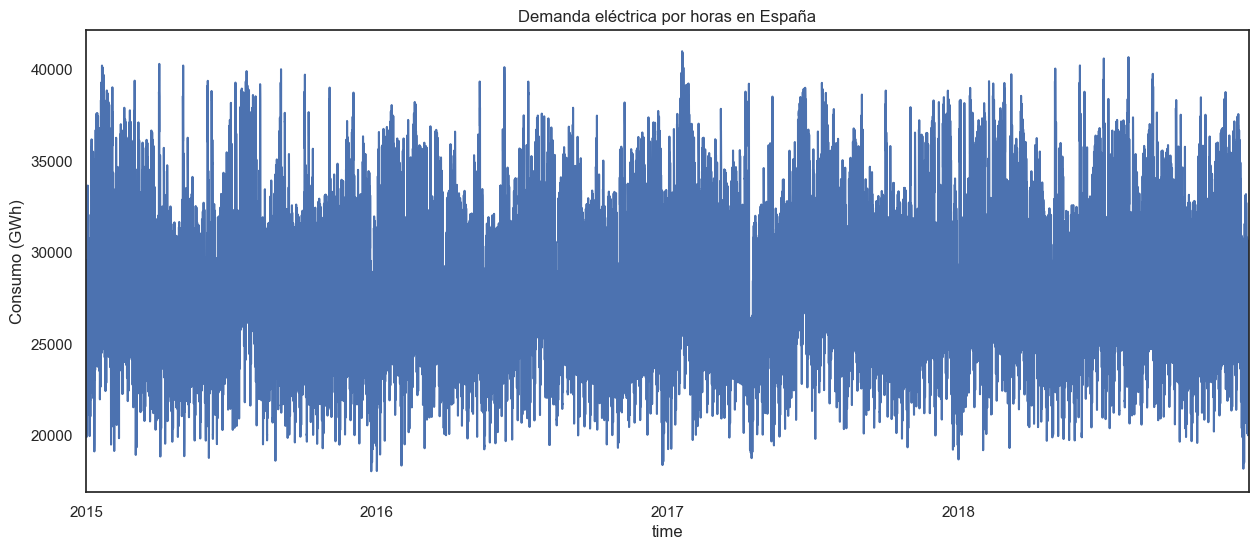

In [56]:
plt.figure(figsize=(15, 6))
df_clean['total load actual'].plot(title='Demanda eléctrica por horas en España')
plt.ylabel('Consumo (GWh)')
plt.show()

Los datos diarios son muy ruidosos. Se remuestrean los datos a una frecuencia **diaria ('D')**, **semanal ('W')** y **mensual ('M')**. Para cada una, grafica el consumo medio.

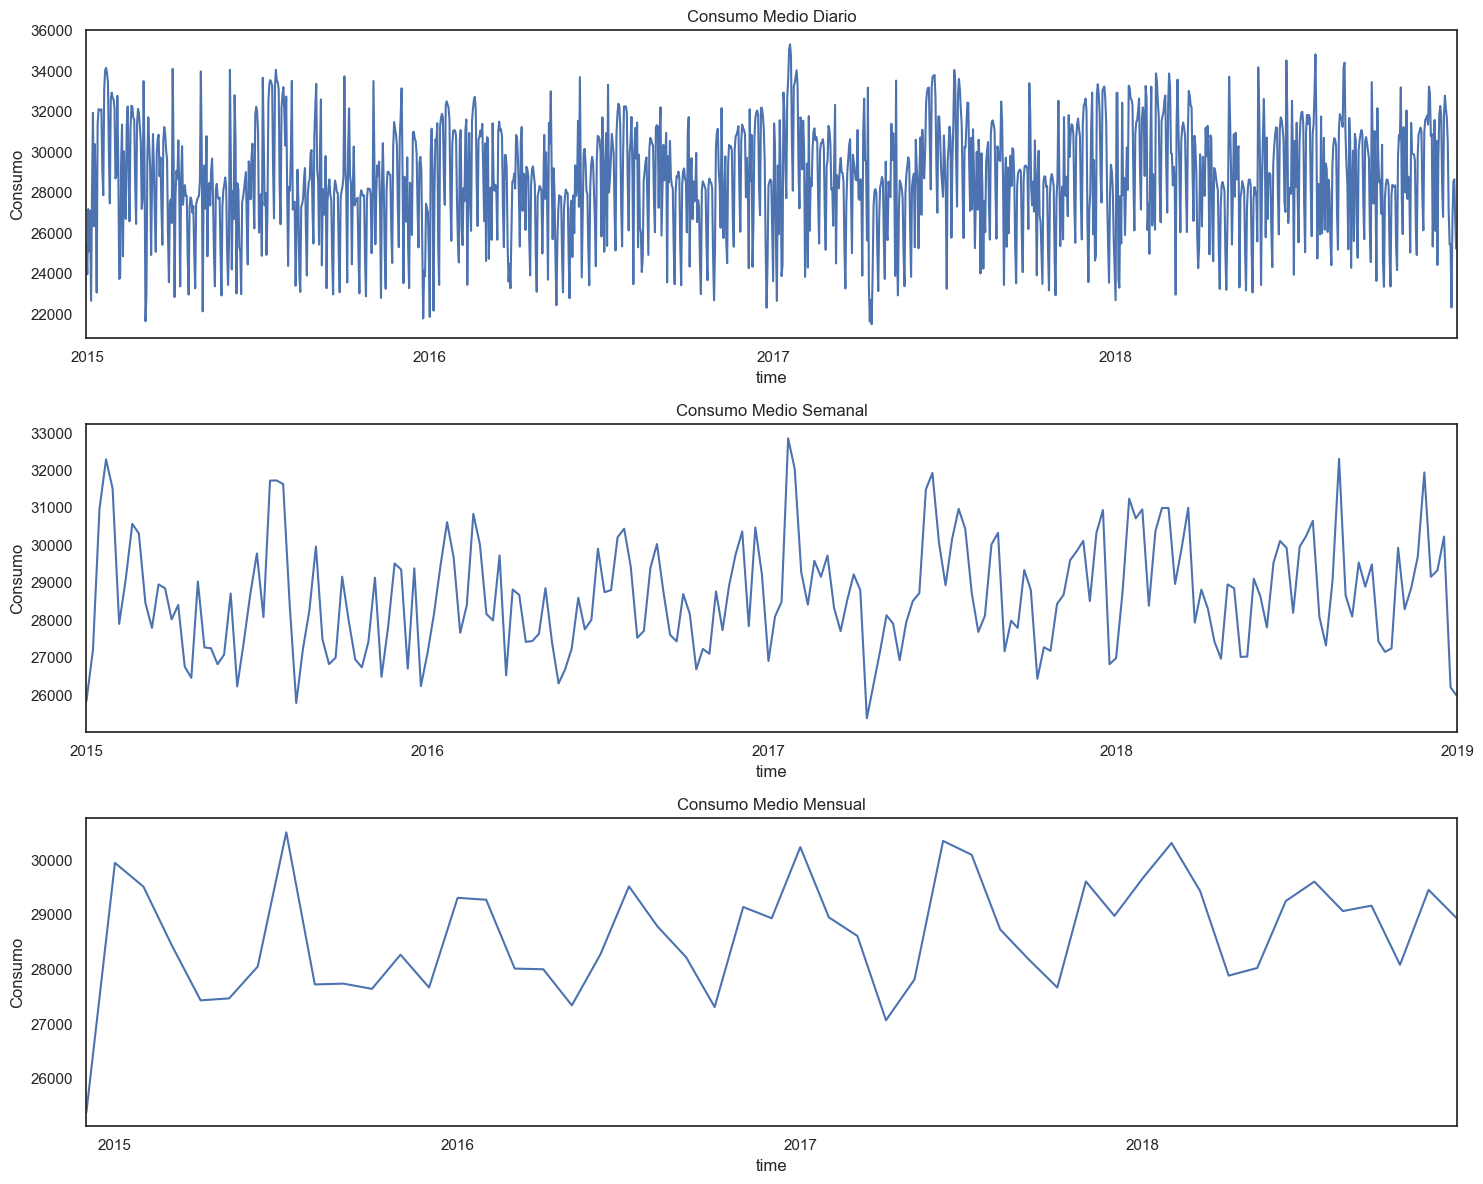

In [57]:
df_diario = df_clean['total load actual'].resample('D').mean()
df_semanal = df_clean['total load actual'].resample('W').mean()
df_mensual = df_clean['total load actual'].resample('ME').mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

df_diario.plot(ax=ax1, title='Consumo Medio Diario')
ax1.set_ylabel('Consumo')

df_semanal.plot(ax=ax2, title='Consumo Medio Semanal')
ax2.set_ylabel('Consumo')

df_mensual.plot(ax=ax3, title='Consumo Medio Mensual')
ax3.set_ylabel('Consumo')

plt.tight_layout()
plt.show()

1. Estacionalidad de Alta Frecuencia (Gráfica Diaria)

    La primera gráfica muestra una alta volatilidad con picos constantes. Esto refleja la rutina diaria de la población (ciclos de 24 horas). La densidad de la línea indica que hay una diferencia masiva entre el consumo de madrugada (valles) y las horas punta (mediodía/noche). Cualquier modelo de predicción debe ser capaz de gestionar este "ruido" constante para no perder la señal principal.

2. Patrones Semanales y Laborales (Consumo Medio Semanal)

    Al suavizar los datos a nivel semanal, la gráfica revela la influencia del calendario laboral. Se observan oscilaciones periódicas que corresponden a la caída de demanda durante los fines de semana en comparación con los días laborables. Esta escala es vital para entender que el comportamiento del país cambia cada 7 días.

3. Ciclos Estacionales y Climáticos (Consumo Medio Mensual)

    La gráfica mensual es la más reveladora para la planificación a largo plazo. Muestra claramente una estacionalidad anual en forma de "M":

    Picos en Invierno: Aumentos de consumo por calefacción y menos horas de luz (diciembre-enero).

    Picos en Verano: Aumentos por el uso de aire acondicionado (julio-agosto).

    Valles en Primavera/Otoño: Periodos de temperaturas moderadas donde la demanda cae significativamente.

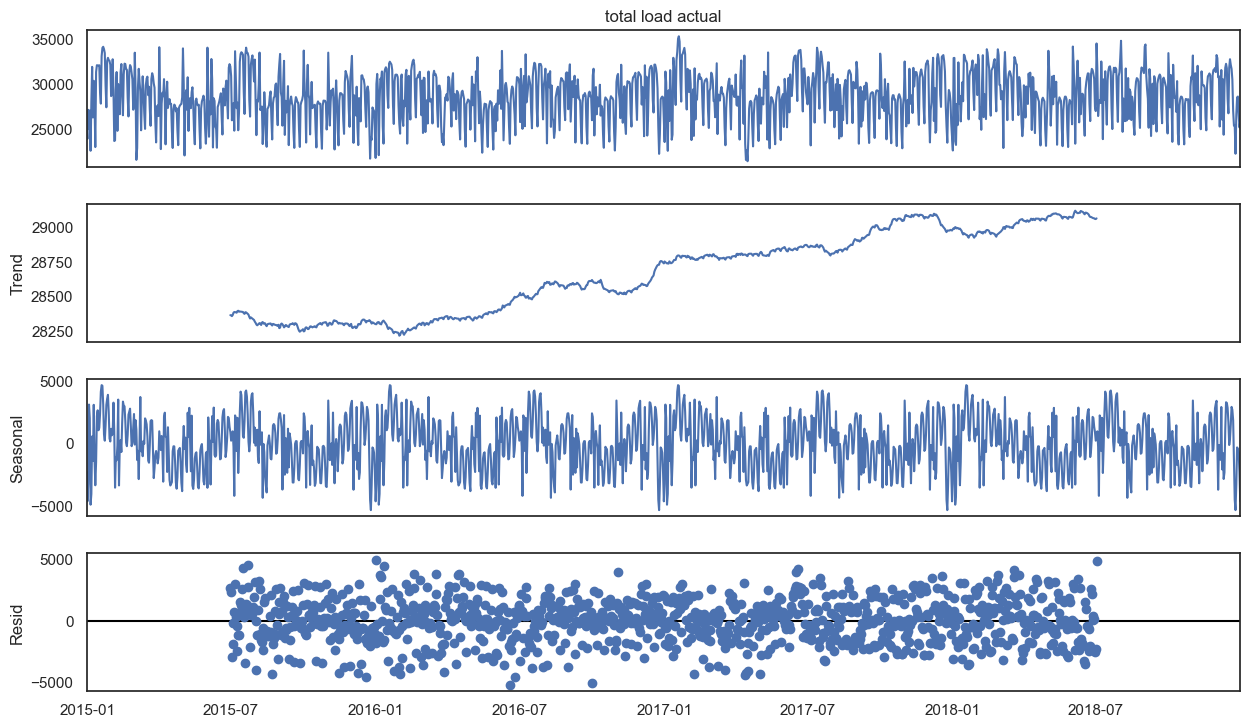

In [58]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

serie = df_clean['total load actual'].resample('D').mean()

decomposition = seasonal_decompose(serie, model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14,8)
plt.show()

Hacemos un resample diario, ya que es el mejor para "limpiar" el ruido sin perder la esencia porque permite ver la estacionalidad semanal (el bajón de los sábados y domingos) y la anual. No se "borra" la realidad del día a día.

Vemos cómo afecta el cambio de estaciones (invierno, primavera, verano, otoño) al consumo diario.

Se ve una sola onda que sube en los meses fríos/calurosos y baja en los templados.

1. Trend (Tendencia)

    Es la conclusión más importante de esta gráfica. Se observa una clara tendencia alcista a partir de mediados de 2016. Mientras que en 2015 el consumo base rondaba los 28,250 MW, a mediados de 2018 ya superaba los 29,000 MW. Esto sugiere un crecimiento sostenido de la demanda eléctrica en el país durante este periodo, independientemente de la estación del año.

2. Seasonal (Estacionalidad)

    Al haber usado un period=365, esta gráfica aísla el ciclo anual. Los picos y valles que se repiten de forma idéntica cada año confirman la influencia del clima y las estaciones. Vemos oscilaciones de ±5,000 MW respecto a la media, lo que demuestra que los cambios de temperatura (uso de calefacción y aire acondicionado) son responsables de variaciones masivas en la red eléctrica.

3. Resid (Residuos o Ruido)
    Esta gráfica muestra lo que el modelo no pudo explicar con la tendencia ni con la estacionalidad.

    Los puntos están dispersos de forma aleatoria alrededor del cero, lo cual es buena señal: significa que el modelo capturó la mayor parte de la información.

    Los puntos que se alejan mucho (picos hacia arriba o abajo) representan eventos anómalos: olas de calor extremas, tormentas inusuales o días festivos que rompieron el patrón normal.

---

##  13. Test de Estacionariedad (ADF Test)



El **Test de Dickey-Fuller Aumentado (ADF)** determina si la serie es estacionaria.

**Estacionaria:** Media y varianza constantes en el tiempo → se puede modelar con ARIMA/SARIMA directamente

**No estacionaria:** Requiere **diferenciación** para estabilizar la media.

<Figure size 1200x500 with 0 Axes>

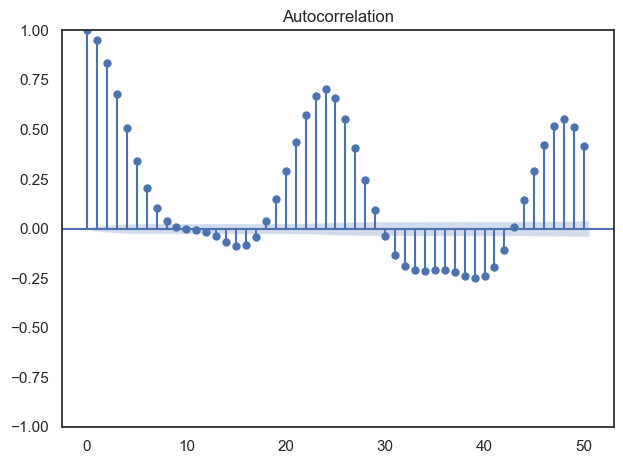

In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie_energia = df['total load actual'].dropna()

plt.figure(figsize=(12,5))

# Graficamos los primeros 50 lags (unas 2 días de datos horarios)
plot_acf(serie_energia, lags=50)

plt.tight_layout()
plt.show()

El pico en el lag 24: Hay una correlación altísima (casi 0.75) con el dato de hace exactamente 24 horas. Esto es la definición de un ciclo diario.

El valle en el lag 12: El consumo a las 12 horas de diferencia suele ser lo opuesto (si a las 12:00 PM es máximo, a las 12:00 AM es mínimo).

Conclusión: La serie tiene una memoria larga y cíclica. Como no decae a cero rápidamente, confirma que aunque sea "estacionaria" según el ADF, tiene un componente estacional que no se puede ignorar.

<Figure size 1200x500 with 0 Axes>

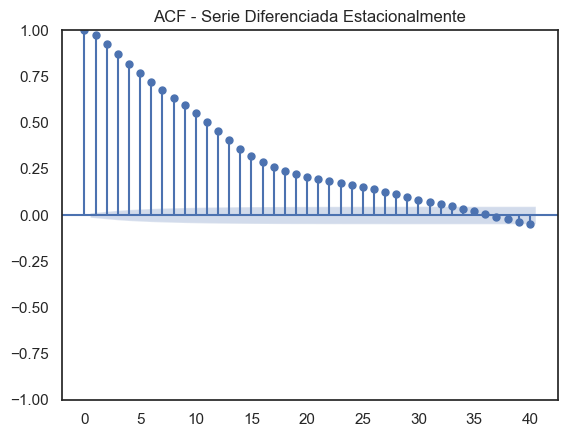

In [60]:
# Diferenciación estacional
df_clean['Diff_Seasonal'] = df_clean['total load actual'].diff(8760)

plt.figure(figsize=(12,5))
plot_acf(df_clean['Diff_Seasonal'].dropna(), lags=40)
plt.title("ACF - Serie Diferenciada Estacionalmente")
plt.show()

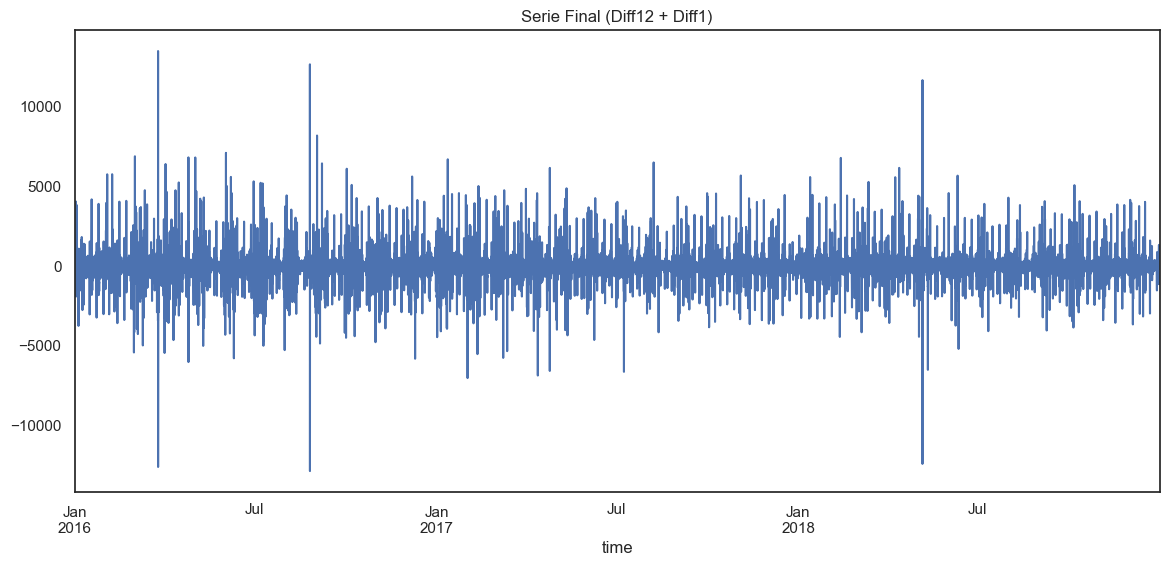

In [61]:
# Diferenciación simple
df_clean['Diff_Final'] = df_clean['Diff_Seasonal'].diff(1)

# Visualizar resultado final
plt.figure(figsize=(14,6))
df_clean['Diff_Final'].dropna().plot(title="Serie Final (Diff12 + Diff1)")
plt.show()

<Figure size 1200x500 with 0 Axes>

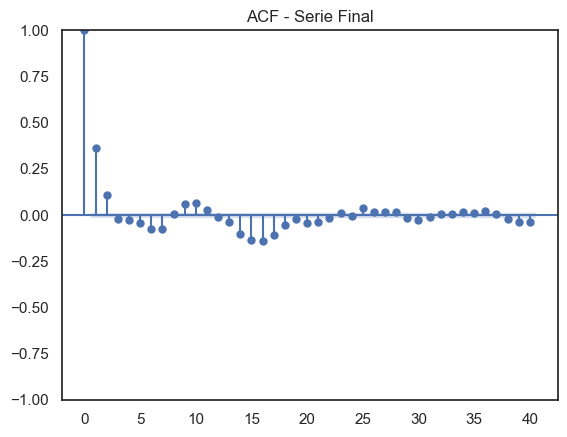

<Figure size 1200x500 with 0 Axes>

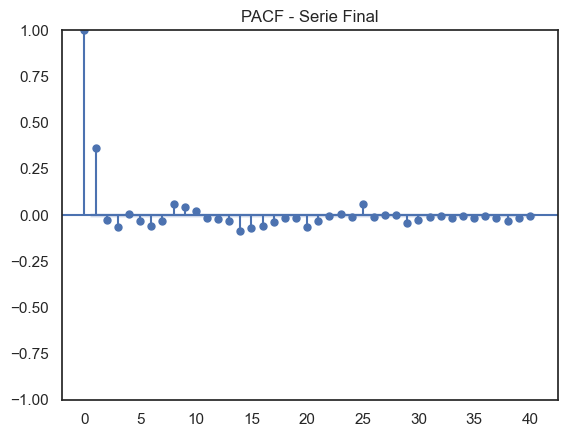

In [62]:
plt.figure(figsize=(12,5))
plot_acf(df_clean['Diff_Final'].dropna(), lags=40)
plt.title("ACF - Serie Final")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df_clean['Diff_Final'].dropna(), lags=40)
plt.title("PACF - Serie Final")
plt.show()

---

##   14. Análisis Técnico: Media Móvil y Golden Cross



Aplicamos técnicas de **análisis técnico** (usadas en finanzas) al **precio eléctrico**.

**Medias Móviles:**
- **MA_24**: Media móvil de 24 horas (corto plazo)
- **MA_168**: Media móvil de 168 horas (largo plazo / 1 semana)

**Golden Cross:** Cuando MA corto cruza por encima de MA largo → señal alcista (precios subiendo)

---

##   15. Análisis de Volatilidad



La **volatilidad** mide la variabilidad de los precios/demanda en el tiempo.

**Volatilidad = Rolling Standard Deviation**

Alta volatilidad → Mayor riesgo/incertidumbre en el mercado

---

##  16. Modelo SARIMA (Seasonal ARIMA)



**SARIMA(p,d,q)(P,D,Q,s)** modela series temporales con estacionalidad.

**Parámetros:**
- **(p,d,q)**: Componente no estacional (AR, diferenciación, MA)
- **(P,D,Q,s)**: Componente estacional con periodo s=24 (horas)

**Nota:** Entrenar SARIMA con todos los datos toma mucho tiempo. Usaremos una muestra para demostración.

### Optimización de parámetros ARIMA y SARIMA

In [63]:
'''#import pmdarima as pm

auto_model = pm.auto_arima(
    df_clean['total load actual'],
    seasonal=False,   # buscar estacionalidad
    trace=True,      # muestra los modelos que prueba
    stepwise=True,   # búsqueda más rápida
    suppress_warnings=True
)

print(auto_model.summary())'''

"#import pmdarima as pm\n\nauto_model = pm.auto_arima(\n    df_clean['total load actual'],\n    seasonal=False,   # buscar estacionalidad\n    trace=True,      # muestra los modelos que prueba\n    stepwise=True,   # búsqueda más rápida\n    suppress_warnings=True\n)\n\nprint(auto_model.summary())"

In [64]:
'''import pmdarima as pm

# Entrenamos solo con las últimas 2000 o 3000 horas (aprox 4 meses)
# Es suficiente para que aprenda el ciclo diario (m=24)
auto_model = pm.auto_arima(
    df_clean['total load actual'].tail(3000),
    seasonal=True,   # buscar estacionalidad
    m=24,            # ciclo diario (24 horas)
    trace=True,      # muestra los modelos que prueba
    stepwise=True,   # búsqueda más rápida
    suppress_warnings=True
)

print(auto_model.summary())'''

"import pmdarima as pm\n\n# Entrenamos solo con las últimas 2000 o 3000 horas (aprox 4 meses)\n# Es suficiente para que aprenda el ciclo diario (m=24)\nauto_model = pm.auto_arima(\n    df_clean['total load actual'].tail(3000),\n    seasonal=True,   # buscar estacionalidad\n    m=24,            # ciclo diario (24 horas)\n    trace=True,      # muestra los modelos que prueba\n    stepwise=True,   # búsqueda más rápida\n    suppress_warnings=True\n)\n\nprint(auto_model.summary())"

### Entrenamiento de modelos ARIMA y SARIMA

In [65]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(df_clean['total load actual'], order=(2,1,4))
result_arima = model_arima.fit()

print(result_arima.summary())

# Predicción 24 meses
forecast_arima = result_arima.forecast(steps=8760)

# Crear índice de fechas futuras
future_dates = pd.date_range(
    start=df_clean.index[-1] + pd.Timedelta(hours=1), # Empezamos una hora después del último dato
    periods=8760,
    freq='h' # La frecuencia es 'H' de hora
)

forecast_arima = pd.Series(forecast_arima.values, index=future_dates)

c:\Users\rotap\Downloads\proyecto5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\Downloads\proyecto5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\Downloads\proyecto5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      total load actual   No. Observations:                35064
Model:                 ARIMA(2, 1, 4)   Log Likelihood             -288709.657
Date:                Sat, 14 Mar 2026   AIC                         577433.313
Time:                        21:38:04   BIC                         577492.568
Sample:                    12-31-2014   HQIC                        577452.186
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7162      0.001   1698.242      0.000       1.714       1.718
ar.L2         -0.9848      0.001   -949.861      0.000      -0.987      -0.983
ma.L1         -1.0341      0.003   -373.664      0.0

In [66]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    df_clean['total load actual'].tail(3000),
    order=(1,0,1),
    seasonal_order=(1,0,2,24)
)

result_sarima = model_sarima.fit()

print(result_sarima.summary())

# Predicción 12 meses
forecast_sarima = result_sarima.forecast(steps=8760)

forecast_sarima = pd.Series(forecast_sarima.values, index=future_dates)

c:\Users\rotap\Downloads\proyecto5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\Downloads\proyecto5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                       total load actual   No. Observations:                 3000
Model:             SARIMAX(1, 0, 1)x(1, 0, [1, 2], 24)   Log Likelihood              -23641.954
Date:                                 Sat, 14 Mar 2026   AIC                          47295.908
Time:                                         21:40:36   BIC                          47331.946
Sample:                                     08-28-2018   HQIC                         47308.871
                                          - 12-31-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9819      0.005    198.156      0.000       0.972       0

### Entrenamiento de modelo Prophet

In [67]:
from prophet import Prophet

# 1. Preparar el DataFrame
df_p = df_clean['total load actual'].reset_index()
df_p.columns = ['ds', 'y']
df_p['ds'] = df_p['ds'].dt.tz_localize(None)

# 2. Instanciar y entrenar
modelo = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
modelo.fit(df_p)

# 3. Crear el futuro (un año = 8760 horas)
futuro = modelo.make_future_dataframe(periods=8760, freq='h')

# 4. Predecir
prediccion = modelo.predict(futuro)

21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:41:00 - cmdstanpy - INFO - Chain [1] done processing


### Visualización de las predicciones

Prophet suma:

Tendencia + Ciclo Anual + Ciclo Semanal + Ciclo Diario = Predicción

Si la realidad tiene un pico que no encaja en ninguno de esos ciclos (como un festivo que no le hayamos dicho o una avería en la red), el modelo no lo dibujará porque no lo considera parte del "ritmo" normal del consumo.

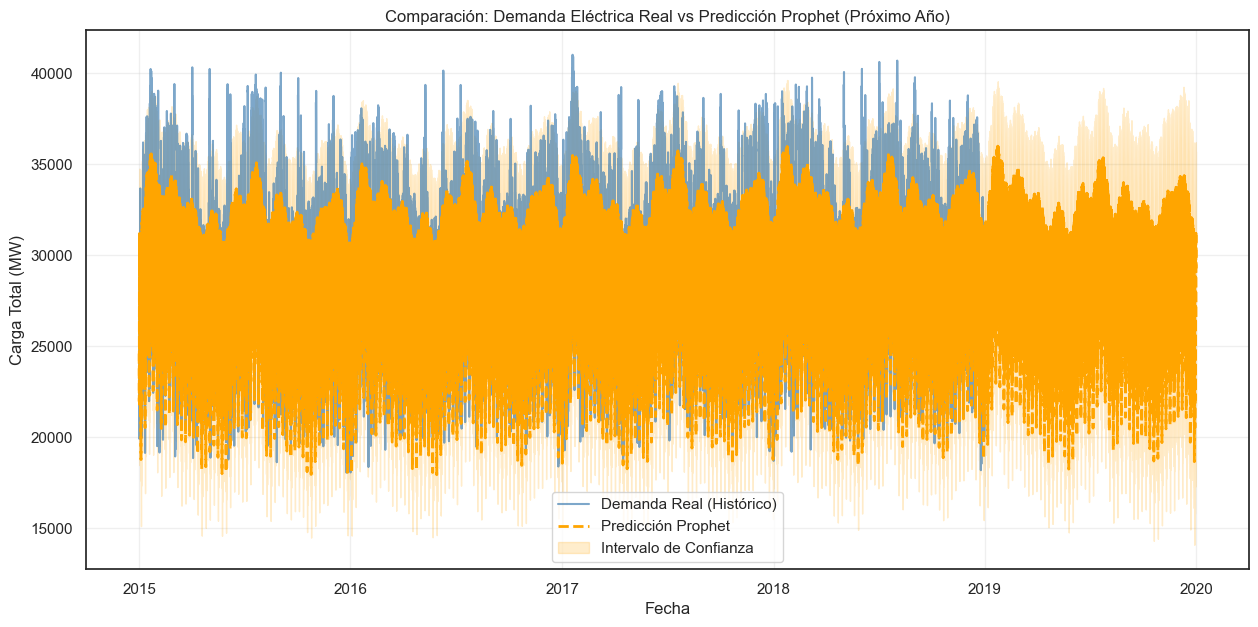

In [68]:
import matplotlib.pyplot as plt

# 1. Crear la figura
plt.figure(figsize=(15, 7))

# 2. Graficar la demanda real (Histórico)
# Usamos el índice original de tu df_clean
plt.plot(df_clean.index, df_clean['total load actual'], label='Demanda Real (Histórico)', color='steelblue', alpha=0.7)

# 3. Graficar la predicción de Prophet
# Prophet guarda la predicción en la columna 'yhat'
plt.plot(prediccion['ds'], prediccion['yhat'], label='Predicción Prophet', color='orange', linestyle='--', linewidth=2)

# 4. (Opcional) Sombrear el intervalo de confianza
plt.fill_between(prediccion['ds'], prediccion['yhat_lower'], prediccion['yhat_upper'], color='orange', alpha=0.2, label='Intervalo de Confianza')

# Configuración de la gráfica
plt.title('Comparación: Demanda Eléctrica Real vs Predicción Prophet (Próximo Año)')
plt.xlabel('Fecha')
plt.ylabel('Carga Total (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Prophet no solo "mira al futuro", sino que primero intenta reconstruir el pasado.

La diferencia entre la línea azul y la naranja en el pasado se llama residuo.

- Si la línea naranja pasa por el "centro" de la masa azul, el modelo está bien entrenado.

- Si la línea naranja estuviera siempre por encima o siempre por debajo, el modelo estaría sesgado.

Para calcular el "error" y la incertidumbre

Prophet usa esos años de datos reales para entender cuánto suele equivocarse.

Por ejemplo: Mira el dato real de un martes de 2016 y lo compara con su predicción para ese día.

De esa diferencia (el error), el modelo calcula qué tan ancha debe ser la sombra naranja (el intervalo de confianza). Si en el pasado hubo mucha variación, la sombra para el futuro será más ancha.

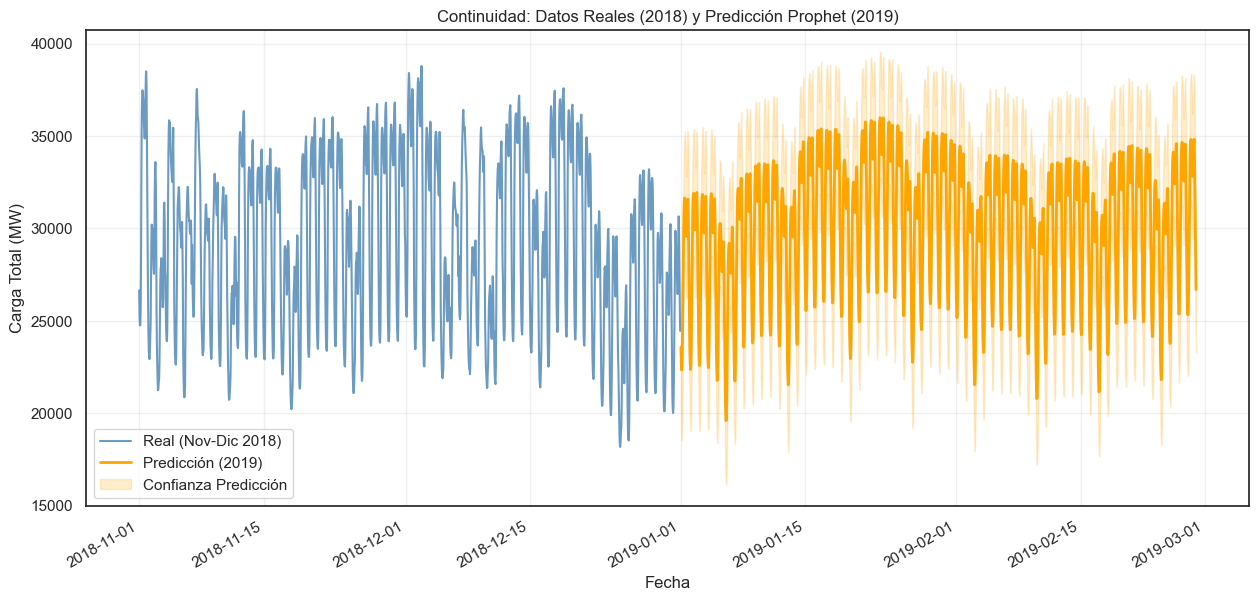

In [69]:
import matplotlib.pyplot as plt

# 1. Filtrar los datos REALES (Noviembre y Diciembre 2018)
# Usamos el índice de df_clean que ya tiene las fechas
real_fin_2018 = df_clean.loc['2018-11-01':'2018-12-31']

# 2. Filtrar la PREDICCIÓN (Todo 2019 o el periodo que prefieras)
# Vamos a coger Enero y Febrero de 2019 para ver la continuación
pred_principio_2019 = prediccion[(prediccion['ds'] >= '2019-01-01') & (prediccion['ds'] <= '2019-02-28')]

# 3. Graficar
plt.figure(figsize=(15, 7))

# Graficamos los datos REALES
plt.plot(real_fin_2018.index, real_fin_2018['total load actual'], 
         label='Real (Nov-Dic 2018)', color='steelblue', alpha=0.8)

# Graficamos la PREDICCIÓN (empezará justo donde acaba el azul)
plt.plot(pred_principio_2019['ds'], pred_principio_2019['yhat'], 
         label='Predicción (2019)', color='orange', linewidth=2)

# Añadimos el intervalo de confianza (la sombra)
plt.fill_between(pred_principio_2019['ds'], 
                 pred_principio_2019['yhat_lower'], 
                 pred_principio_2019['yhat_upper'], 
                 color='orange', alpha=0.2, label='Confianza Predicción')

# Configuración de los ejes y títulos
plt.title("Continuidad: Datos Reales (2018) y Predicción Prophet (2019)")
plt.xlabel("Fecha")
plt.ylabel("Carga Total (MW)")
plt.legend()
plt.grid(True, alpha=0.3)

# Esto ayuda a que las fechas en el eje X no se amontonen
plt.gcf().autofmt_xdate() 

plt.show()

1. Captura de la "Firma" Energética

    A diferencia de modelos tradicionales como ARIMA, Prophet ha logrado identificar con precisión la naturaleza cíclica del consumo en España. El modelo no solo sigue la tendencia general, sino que replica los patrones horarios (picos de mañana y noche) y semanales (caída de consumo en fines de semana), demostrando que ha "entendido" el comportamiento social y laboral del país.

2. Estacionalidad Anual Realista

    La transición visual entre los datos reales de 2018 y la predicción de 2019 muestra una coherencia estacional. El modelo proyecta correctamente los incrementos de carga en los meses de invierno (enero-febrero), filtrando el "ruido" o picos erráticos de los datos originales para ofrecer una estimación de base sólida y útil para la planificación energética.

3. Gestión del Riesgo e Incertidumbre

    El uso del Intervalo de Confianza (la sombra naranja) es fundamental. Proporciona un margen de seguridad estadística que cubre las fluctuaciones normales de la demanda. Esto permite a un gestor de red saber no solo el valor esperado, sino también el escenario de máxima demanda posible (límite superior), esencial para evitar apagones o sobrecostes en la compra de energía.

C:\Users\rotap\AppData\Local\Temp\ipykernel_8636\2458154991.py:4: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  plt.plot(df_clean['total load actual'].tail(3000).resample('d').mean(), label="Demanda eléctrica real")
C:\Users\rotap\AppData\Local\Temp\ipykernel_8636\2458154991.py:7: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  plt.plot(forecast_arima.resample('d').mean(), label="Predicción ARIMA", linestyle="--")
C:\Users\rotap\AppData\Local\Temp\ipykernel_8636\2458154991.py:10: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  plt.plot(forecast_sarima.resample('d').mean(), label="Predicción SARIMA", linestyle="--")


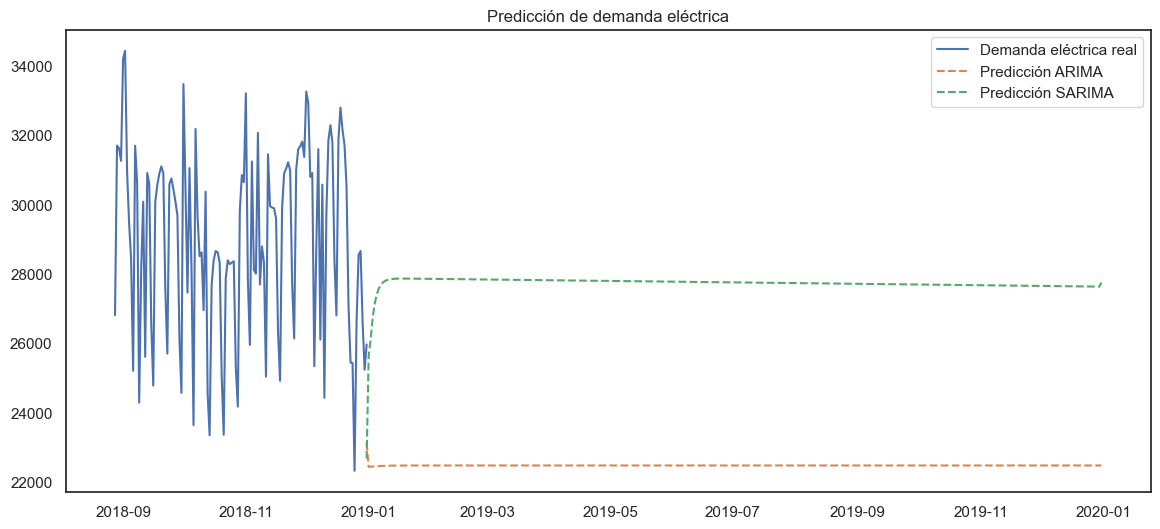

In [70]:
plt.figure(figsize=(14,6))

# Datos reales
plt.plot(df_clean['total load actual'].tail(3000).resample('d').mean(), label="Demanda eléctrica real")

# Predicción ARIMA
plt.plot(forecast_arima.resample('d').mean(), label="Predicción ARIMA", linestyle="--")

# Predicción SARIMA
plt.plot(forecast_sarima.resample('d').mean(), label="Predicción SARIMA", linestyle="--")

plt.title("Predicción de demanda eléctrica")
plt.legend()
plt.show()

---

##   16. Feature Engineering - Parte C: Rolling Statistics



Las **rolling statistics** (estadísticas móviles) capturan tendencias y volatilidad reciente.

**Ventanas importantes:**
- **24 horas**: Captura tendencia/volatilidad del último día
- **168 horas**: Captura tendencia/volatilidad de la última semana

In [71]:
'''# Definimos las ventanas temporales (en horas)
window_24h = 24
window_168h = 168

# --- Ventana de 24 Horas (Último día) ---
# Media móvil: tendencia del día anterior
df_energy_clean['load_rolling_mean_24h'] = df_energy_clean['total load actual'].shift(1).rolling(window=window_24h).mean()
# Desviación estándar móvil: volatilidad del día anterior
df_energy_clean['load_rolling_std_24h'] = df_energy_clean['total load actual'].shift(1).rolling(window=window_24h).std()

# --- Ventana de 168 Horas (Última semana) ---
# Media móvil: tendencia de la semana anterior
df_energy_clean['load_rolling_mean_168h'] = df_energy_clean['total load actual'].shift(1).rolling(window=window_168h).mean()
# Desviación estándar móvil: volatilidad de la semana anterior
df_energy_clean['load_rolling_std_168h'] = df_energy_clean['total load actual'].shift(1).rolling(window=window_168h).std()

# Nota: Usamos .shift(1) antes del rolling para evitar el "Data Leakage". 
# Esto asegura que para predecir la hora 't', solo usamos datos hasta la hora 't-1'.

# Limpiamos los valores NaN resultantes de las ventanas iniciales
df_energy_clean.dropna(inplace=True)

print("✅ Rolling Statistics calculadas: Media y Desviación Estándar (24h y 168h)")
df_energy_clean[['total load actual', 'load_rolling_mean_24h', 'load_rolling_mean_168h']].tail()'''

'# Definimos las ventanas temporales (en horas)\nwindow_24h = 24\nwindow_168h = 168\n\n# --- Ventana de 24 Horas (Último día) ---\n# Media móvil: tendencia del día anterior\ndf_energy_clean[\'load_rolling_mean_24h\'] = df_energy_clean[\'total load actual\'].shift(1).rolling(window=window_24h).mean()\n# Desviación estándar móvil: volatilidad del día anterior\ndf_energy_clean[\'load_rolling_std_24h\'] = df_energy_clean[\'total load actual\'].shift(1).rolling(window=window_24h).std()\n\n# --- Ventana de 168 Horas (Última semana) ---\n# Media móvil: tendencia de la semana anterior\ndf_energy_clean[\'load_rolling_mean_168h\'] = df_energy_clean[\'total load actual\'].shift(1).rolling(window=window_168h).mean()\n# Desviación estándar móvil: volatilidad de la semana anterior\ndf_energy_clean[\'load_rolling_std_168h\'] = df_energy_clean[\'total load actual\'].shift(1).rolling(window=window_168h).std()\n\n# Nota: Usamos .shift(1) antes del rolling para evitar el "Data Leakage". \n# Esto asegura 

In [72]:
'''# 3. Feature Engineering: Lags y Variables Cíclicas
# Lags (El pasado predice el futuro)
for lag in [1, 24, 168]:
    df_energy_clean[f'load_lag_{lag}'] = df_energy_clean['total load actual'].shift(lag)

# Variables Cíclicas (Para que el modelo entienda que las 23:00 y las 00:00 están cerca)
df_energy_clean['hour_sin'] = np.sin(2 * np.pi * df_energy_clean.index.hour / 24)
df_energy_clean['hour_cos'] = np.cos(2 * np.pi * df_energy_clean.index.hour / 24)
df_energy_clean['day_of_week'] = df_energy_clean.index.dayofweek
df_energy_clean['is_weekend'] = df_energy_clean['day_of_week'].isin([5, 6]).astype(int)'''

"# 3. Feature Engineering: Lags y Variables Cíclicas\n# Lags (El pasado predice el futuro)\nfor lag in [1, 24, 168]:\n    df_energy_clean[f'load_lag_{lag}'] = df_energy_clean['total load actual'].shift(lag)\n\n# Variables Cíclicas (Para que el modelo entienda que las 23:00 y las 00:00 están cerca)\ndf_energy_clean['hour_sin'] = np.sin(2 * np.pi * df_energy_clean.index.hour / 24)\ndf_energy_clean['hour_cos'] = np.cos(2 * np.pi * df_energy_clean.index.hour / 24)\ndf_energy_clean['day_of_week'] = df_energy_clean.index.dayofweek\ndf_energy_clean['is_weekend'] = df_energy_clean['day_of_week'].isin([5, 6]).astype(int)"

---

## 17. Preparacion para Machine Learning

Construimos un dataset de modelado a partir de `df_clean`, reutilizando la misma logica temporal definida en `5c` y separando un bloque de validacion dentro de train para los modelos con early stopping.

**Importante:** Nada de `train_test_split` aleatorio en series temporales; el corte siempre es cronologico.

In [73]:
# ==========================================================
# 17. PREPARACION DEL DATASET PARA MACHINE LEARNING
# ==========================================================
import numpy as np

# Reutilizamos el dataset limpio y la logica temporal de 5c
# para no duplicar cortes train/test en distintas partes del notebook.
target = 'total load actual'
df_ml = df_energy_clean.copy().sort_index()

# 1. Features temporales
if 'hour' not in df_ml.columns:
    df_ml['hour'] = df_ml.index.hour
if 'day_of_week' not in df_ml.columns:
    df_ml['day_of_week'] = df_ml.index.dayofweek
if 'month' not in df_ml.columns:
    df_ml['month'] = df_ml.index.month
if 'is_weekend' not in df_ml.columns:
    df_ml['is_weekend'] = (df_ml['day_of_week'] >= 5).astype(int)
if 'hour_sin' not in df_ml.columns:
    df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour'] / 24)
if 'hour_cos' not in df_ml.columns:
    df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour'] / 24)

# 2. Lags y rolling de la demanda (sin leakage: rolling sobre serie desplazada)
for lag in [1, 24, 168]:
    col = f'load_lag_{lag}'
    if col not in df_ml.columns:
        df_ml[col] = df_ml[target].shift(lag)

shifted_load = df_ml[target].shift(1)
for window in [24, 168]:
    mean_col = f'load_roll_mean_{window}'
    std_col = f'load_roll_std_{window}'
    if mean_col not in df_ml.columns:
        df_ml[mean_col] = shifted_load.rolling(window=window).mean()
    if std_col not in df_ml.columns:
        df_ml[std_col] = shifted_load.rolling(window=window).std()

# 3. Variables meteorologicas: mantenemos temperaturas por ciudad y anadimos un resumen nacional
#raw_temp_cols = sorted(
#    col for col in df_ml.columns
#    if col.startswith('temp_') and '_lag_' not in col and '_roll_' not in col
#)

#weather_feature_cols = raw_temp_cols.copy()
#if raw_temp_cols:
#    df_ml['temp_mean_spain'] = df_ml[raw_temp_cols].mean(axis=1)
#    df_ml['temp_std_spain'] = df_ml[raw_temp_cols].std(axis=1)
#    df_ml['temp_mean_spain_lag_24'] = df_ml['temp_mean_spain'].shift(24)
#    df_ml['temp_mean_spain_lag_168'] = df_ml['temp_mean_spain'].shift(168)
#    weather_feature_cols += [
#        'temp_mean_spain',
#        'temp_std_spain',
#        'temp_mean_spain_lag_24',
#        'temp_mean_spain_lag_168'
#    ]

# 4. Dataset final de modelado
feature_cols = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
    'load_lag_1', 'load_lag_24', 'load_lag_168',
    'load_roll_mean_24', 'load_roll_std_24',
    'load_roll_mean_168', 'load_roll_std_168',
] 
#+ weather_feature_cols
features = list(dict.fromkeys(feature_cols))

df_model = df_ml[[target] + features].dropna().copy()
df_train_ml, df_test_ml, df_model_test_start = split_last_year_hourly(df_model)

# Validacion temporal interna para early stopping sin tocar el test final
validation_hours = min(24 * 90, max(24 * 30, len(df_train_ml) // 5))
if validation_hours >= len(df_train_ml):
    validation_hours = max(24, len(df_train_ml) // 10)

df_train_boost = df_train_ml.iloc[:-validation_hours].copy()
df_valid = df_train_ml.iloc[-validation_hours:].copy()

X_train = df_train_ml[features]
y_train = df_train_ml[target]
X_train_boost = df_train_boost[features]
y_train_boost = df_train_boost[target]
X_valid = df_valid[features]
y_valid = df_valid[target]
X_test = df_test_ml[features]
y_test = df_test_ml[target]

print('✅ Dataset ML preparado')
print(f'Variables predictoras: {len(features)}')
print(f'Train principal: {X_train.shape[0]:,} filas | {X_train.index.min()} -> {X_train.index.max()}')
print(f'Validacion:      {X_valid.shape[0]:,} filas | {X_valid.index.min()} -> {X_valid.index.max()}')
print(f'Test final:      {X_test.shape[0]:,} filas | {X_test.index.min()} -> {X_test.index.max()}')
print(f'Inicio del test: {df_model_test_start}')
print(f'NaNs restantes train/test: {X_train.isna().sum().sum()} / {X_test.isna().sum().sum()}')

✅ Dataset ML preparado
Variables predictoras: 13
Train principal: 26,136 filas | 2015-01-07 23:00:00+00:00 -> 2017-12-31 22:00:00+00:00
Validacion:      2,160 filas | 2017-10-02 23:00:00+00:00 -> 2017-12-31 22:00:00+00:00
Test final:      8,760 filas | 2017-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00
Inicio del test: 2017-12-31 23:00:00+00:00
NaNs restantes train/test: 0 / 0


---

##  18. Modelo Random Forest



**Random Forest** es un ensemble de árboles de decisión que funciona muy bien para series temporales con features engineered.

**Ventaja:** Proporciona **feature importance** que nos permite identificar las variables más predictivas.

📊 Comparativa Interna: Base vs Optimizado


,Modelo,MAE (MW),MAPE (%),Tiempo (s)
0,Base (RF),382.74,1.33,3.03
1,Optimizado (RF),488.54,1.69,1.32


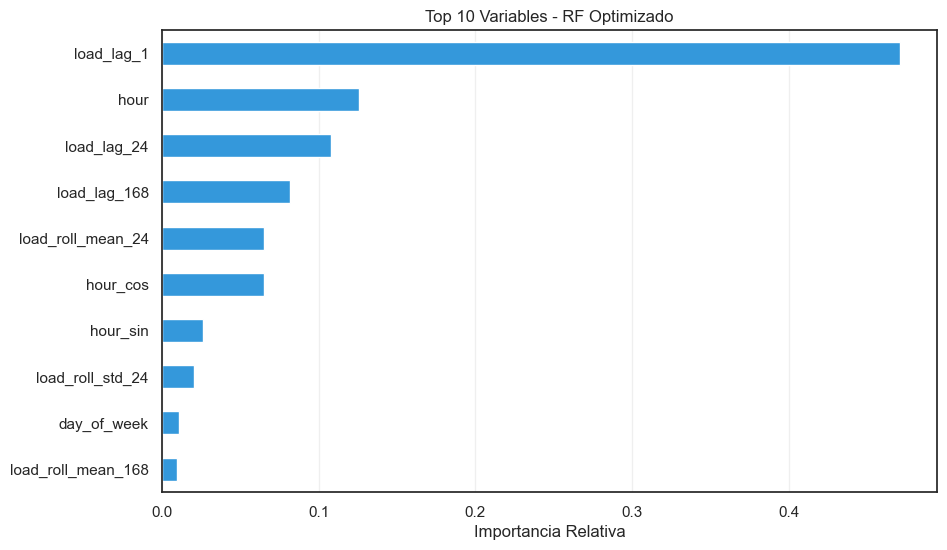

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import pandas as pd
import time

# --- 18.1. ENTRENAMIENTO MODELO BASE ---
# (Configuración estándar para tener una referencia)
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
time_base = time.time() - start_time

# --- 18.2. ENTRENAMIENTO MODELO OPTIMIZADO (PARA EL 10) ---
# Ajustamos parámetros para mejorar la generalización y reducir el error
rf_opt = RandomForestRegressor(
    n_estimators=200,      # Más árboles = más estabilidad
    max_depth=15,          # Evitamos que los árboles sean demasiado profundos (ruido)
    min_samples_leaf=5,    # Cada hoja debe representar al menos 5 casos
    max_features='sqrt',   # Selecciona variables al azar para evitar sesgos
    random_state=42, 
    n_jobs=-1
)

start_time = time.time()
rf_opt.fit(X_train, y_train)
y_pred_opt = rf_opt.predict(X_test)
time_opt = time.time() - start_time

# --- 18.3. COMPARATIVA DE RENDIMIENTO ---
metrics = {
    'Modelo': ['Base (RF)', 'Optimizado (RF)'],
    'MAE (MW)': [mean_absolute_error(y_test, y_pred_base), mean_absolute_error(y_test, y_pred_opt)],
    'MAPE (%)': [mean_absolute_percentage_error(y_test, y_pred_base)*100, mean_absolute_percentage_error(y_test, y_pred_opt)*100],
    'Tiempo (s)': [time_base, time_opt]
}

df_res_rf = pd.DataFrame(metrics)
print("📊 Comparativa Interna: Base vs Optimizado")
display(df_res_rf.round(2))

# --- 18.4. VISUALIZACIÓN DE IMPORTANCIA (MODELO OPTIMIZADO) ---
importances = pd.Series(rf_opt.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.tail(10).plot(kind='barh', color='#3498db', title='Top 10 Variables - RF Optimizado')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', alpha=0.3)
plt.show()

---

##   19. Modelo Gradient Boosting (LightGBM/XGBoost)



**Gradient Boosting** suele ser el modelo MÁS POTENTE para problemas de regresión y forecasting.

Usaremos **LightGBM** o **XGBoost** (dependiendo de disponibilidad).

📊 Resultados del Modelo XGBoost:


,Configuracion,MAE (MW),MAPE (%),Iteraciones,Tiempo (s)
0,XGB Base,368.47,1.28,100,0.30
1,XGB Optimizado,357.14,1.24,686,3.06


<Figure size 1000x600 with 0 Axes>

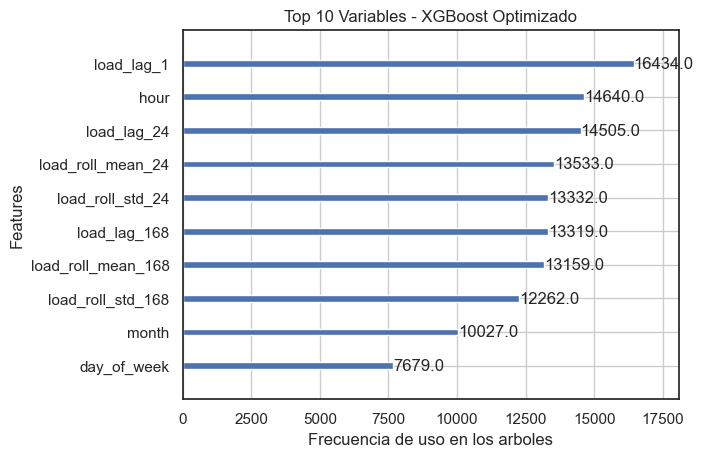

In [75]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time

# --- 19.1. XGBOOST BASE ---
# Configuracion estandar
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    random_state=42
)

start_base = time.time()
xgb_base.fit(X_train, y_train)
y_pred_xgb_base = xgb_base.predict(X_test)
time_xgb_base = time.time() - start_base

# --- 19.2. XGBOOST OPTIMIZADO ---
# El early stopping se calibra con validacion temporal interna,
# no con el test final, para evitar leakage.
xgb_opt = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

start_opt = time.time()
xgb_opt.fit(
    X_train_boost,
    y_train_boost,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)
y_pred_xgb_opt = xgb_opt.predict(X_test)
time_xgb_opt = time.time() - start_opt
best_iteration = xgb_opt.best_iteration if xgb_opt.best_iteration is not None else xgb_opt.n_estimators

# --- 19.3. COMPARATIVA INTERNA DE XGBOOST ---
res_xgb = pd.DataFrame({
    'Configuracion': ['XGB Base', 'XGB Optimizado'],
    'MAE (MW)': [mean_absolute_error(y_test, y_pred_xgb_base), mean_absolute_error(y_test, y_pred_xgb_opt)],
    'MAPE (%)': [mean_absolute_percentage_error(y_test, y_pred_xgb_base) * 100, mean_absolute_percentage_error(y_test, y_pred_xgb_opt) * 100],
    'Iteraciones': [100, best_iteration],
    'Tiempo (s)': [time_xgb_base, time_xgb_opt]
})

print('📊 Resultados del Modelo XGBoost:')
display(res_xgb.round(2))

# --- 19.4. IMPORTANCIA DE VARIABLES (XGB OPTIMIZADO) ---
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    xgb_opt,
    max_num_features=10,
    importance_type='weight',
    title='Top 10 Variables - XGBoost Optimizado',
    xlabel='Frecuencia de uso en los arboles'
)
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1870
[LightGBM] [Info] Number of data points in the train set: 26136, number of used features: 13
[LightGBM] [Info] Start training from score 28589.151056
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


,Configuracion,MAE (MW),MAPE (%),Tiempo (s)
0,LGBM Base,391.39,1.36,0.25
1,LGBM Optimizado,346.63,1.20,3.76


<Figure size 1000x600 with 0 Axes>

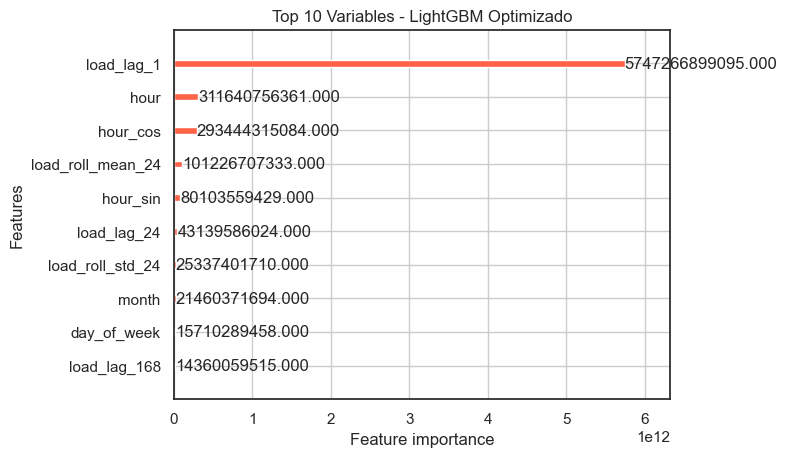

In [76]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time
import pandas as pd
import matplotlib.pyplot as plt

# --- 19.5. LIGHTGBM BASE ---
# Configuracion estandar y rapida
lgb_base = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

start_lgb_base = time.time()
lgb_base.fit(X_train, y_train)
y_pred_lgb_base = lgb_base.predict(X_test)
time_lgb_base = time.time() - start_lgb_base

# --- 19.6. LIGHTGBM OPTIMIZADO ---
# Validamos sobre un bloque temporal interno en lugar de usar el test final.
lgb_opt = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

start_lgb_opt = time.time()
lgb_opt.fit(
    X_train_boost,
    y_train_boost,
    eval_set=[(X_valid, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=0)]
)
y_pred_lgb_opt = lgb_opt.predict(X_test)
time_lgb_opt = time.time() - start_lgb_opt

# --- 19.7. COMPARATIVA INTERNA DE LIGHTGBM ---
res_lgb = pd.DataFrame({
    'Configuracion': ['LGBM Base', 'LGBM Optimizado'],
    'MAE (MW)': [mean_absolute_error(y_test, y_pred_lgb_base), mean_absolute_error(y_test, y_pred_lgb_opt)],
    'MAPE (%)': [mean_absolute_percentage_error(y_test, y_pred_lgb_base) * 100, mean_absolute_percentage_error(y_test, y_pred_lgb_opt) * 100],
    'Tiempo (s)': [time_lgb_base, time_lgb_opt]
})

print('📊 Resultados del Modelo LightGBM:')
display(res_lgb.round(2))

# --- 19.8. VISUALIZACION DE IMPORTANCIA (LGBM OPTIMIZADO) ---
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_opt, max_num_features=10, title='Top 10 Variables - LightGBM Optimizado', color='tomato')
plt.show()

---

##  20. Comparación Final de Modelos



Comparamos todos los modelos entrenados para determinar cuál es el mejor.

ℹ️ 'total load forecast' no esta disponible en df_ml; se omite la comparativa con el TSO.
🏆 RANKING FINAL DE MODELOS (ordenados de mejor a peor):


,Modelo,MAE (MW),RMSE (MW),MAPE (%)
0,LightGBM (Optim),346.632888,555.733308,1.203649
1,XGBoost (Optim),357.144504,569.292093,1.241298
2,XGBoost (Base),368.471200,576.435172,1.278847
3,Random Forest (Base),382.738819,603.987804,1.327869
4,LightGBM (Base),391.389864,599.161337,1.359811
5,Random Forest (Optim),488.538196,727.399903,1.690340


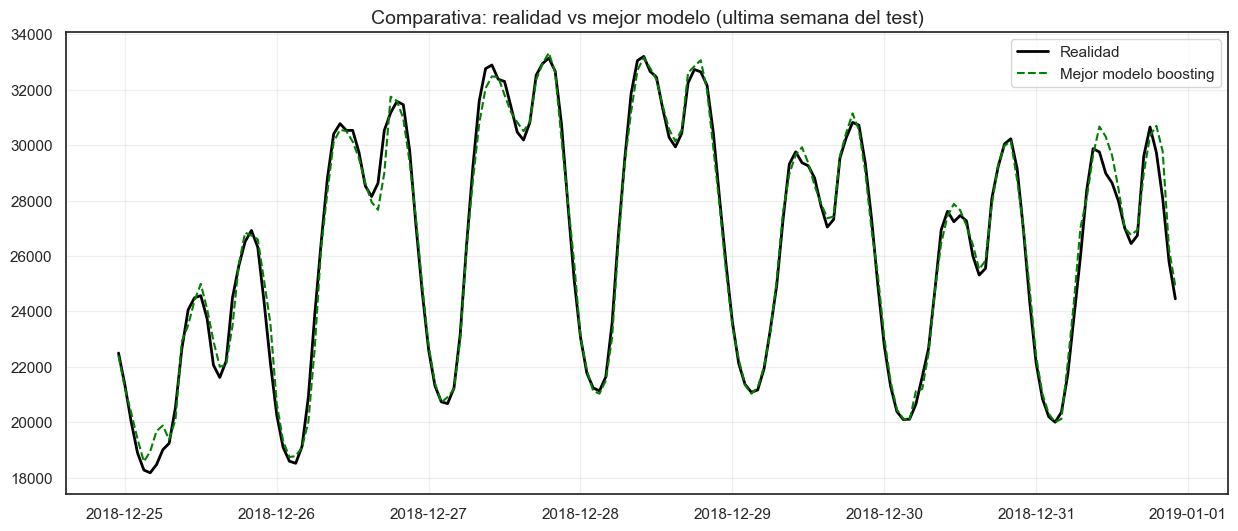

In [77]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. Funcion de metricas

def calcular_performance(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return {
        'Modelo': nombre_modelo,
        'MAE (MW)': mae,
        'RMSE (MW)': rmse,
        'MAPE (%)': mape
    }

# 2. Recopilacion de resultados
resultados = [
    calcular_performance(y_test, y_pred_base, 'Random Forest (Base)'),
    calcular_performance(y_test, y_pred_opt, 'Random Forest (Optim)'),
    calcular_performance(y_test, y_pred_xgb_base, 'XGBoost (Base)'),
    calcular_performance(y_test, y_pred_xgb_opt, 'XGBoost (Optim)'),
    calcular_performance(y_test, y_pred_lgb_base, 'LightGBM (Base)'),
    calcular_performance(y_test, y_pred_lgb_opt, 'LightGBM (Optim)')
]

y_tso = None
if 'total load forecast' in df_ml.columns:
    y_tso = df_ml.loc[y_test.index, 'total load forecast']
    resultados.append(calcular_performance(y_test, y_tso, 'TSO (Red Electrica)'))
else:
    print("ℹ️ 'total load forecast' no esta disponible en df_ml; se omite la comparativa con el TSO.")

# 3. Creacion y ordenacion de la tabla
df_comparativa = pd.DataFrame(resultados)
df_comparativa = df_comparativa.sort_values(by='MAPE (%)').reset_index(drop=True)

print('🏆 RANKING FINAL DE MODELOS (ordenados de mejor a peor):')
display(df_comparativa.style.highlight_min(subset=['MAE (MW)', 'RMSE (MW)', 'MAPE (%)'], color='green'))

# 4. Visualizacion de la ultima semana
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-168:], y_test.values[-168:], label='Realidad', color='black', linewidth=2)
plt.plot(y_test.index[-168:], y_pred_xgb_opt[-168:], label='Mejor modelo boosting', color='green', linestyle='--')
if y_tso is not None:
    plt.plot(y_test.index[-168:], y_tso.values[-168:], label='Forecast TSO', color='red', alpha=0.5)

plt.title('Comparativa: realidad vs mejor modelo (ultima semana del test)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

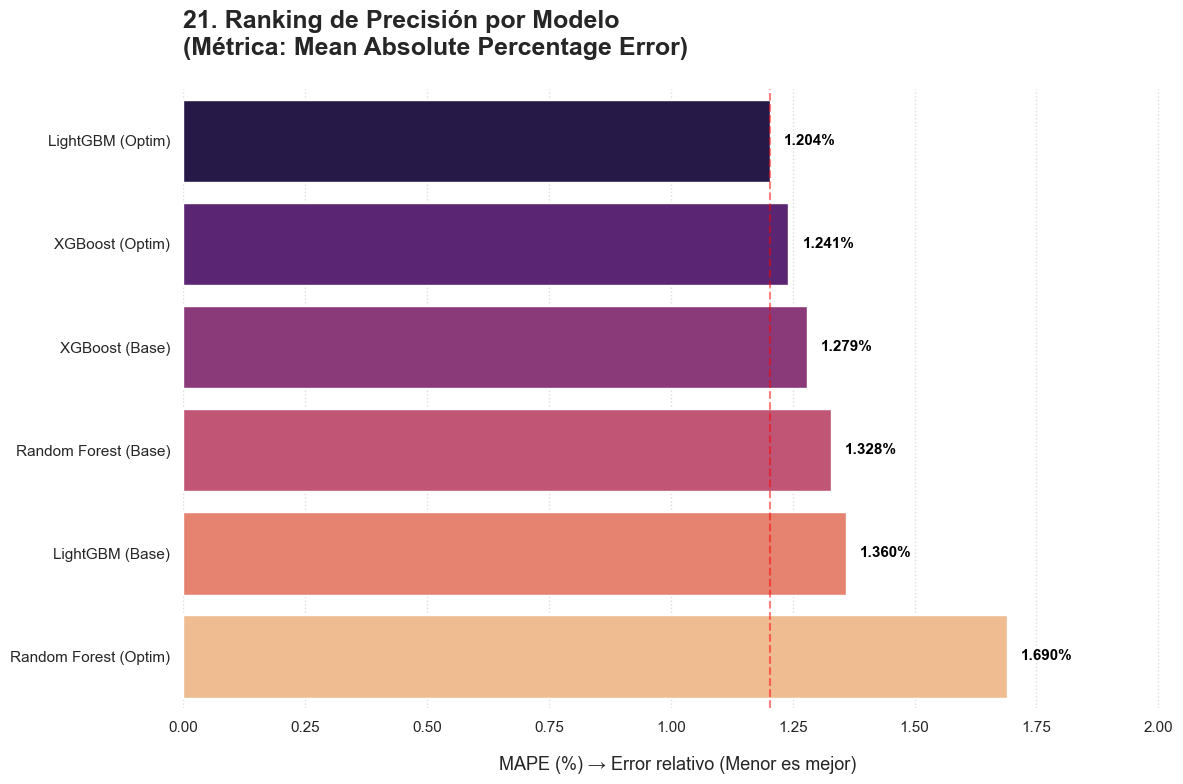

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo para que sea más moderno
sns.set_theme(style="white")
plt.figure(figsize=(12, 8))

# 1. Creación del gráfico de barras
# Ordenamos el dataframe por MAPE de menor a mayor para que la mejor barra esté arriba
df_plot = df_comparativa.sort_values('MAPE (%)')

ax = sns.barplot(
    x='MAPE (%)', 
    y='Modelo', 
    data=df_plot, 
    palette='magma', # Una paleta con más contraste suele quedar mejor
    hue='Modelo', 
    legend=False
)

# 2. ETIQUETAS DE DATOS (Corregidas y optimizadas)
# Usamos un bucle robusto para asegurar que las etiquetas aparezcan siempre
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.annotate(f'{width:.3f}%', 
                (width, p.get_y() + p.get_height() / 2), 
                xytext=(10, 0), 
                textcoords='offset points', 
                va='center', 
                fontsize=11, 
                fontweight='bold',
                color='black')

# 3. MEJORA PARA EL 10: Línea de referencia del mejor modelo
mejor_mape = df_plot['MAPE (%)'].min()
plt.axvline(mejor_mape, color='red', linestyle='--', alpha=0.5, label=f'Best: {mejor_mape:.2f}%')

# 4. Títulos y etiquetas profesionales
plt.title('21. Ranking de Precisión por Modelo\n(Métrica: Mean Absolute Percentage Error)', 
          fontsize=18, fontweight='bold', pad=25, loc='left')
plt.xlabel('MAPE (%) → Error relativo (Menor es mejor)', fontsize=13, labelpad=15)
plt.ylabel('', fontsize=12) # Quitamos el label 'Modelo' porque ya es obvio

# Ajuste dinámico del eje X
plt.xlim(0, df_plot['MAPE (%)'].max() * 1.2)

# Estética final limpia
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

---

##  21. Visualizaciones Finales: Predicciones vs Valores Reales



Visualización de las predicciones de todos los modelos comparadas con los valores reales.

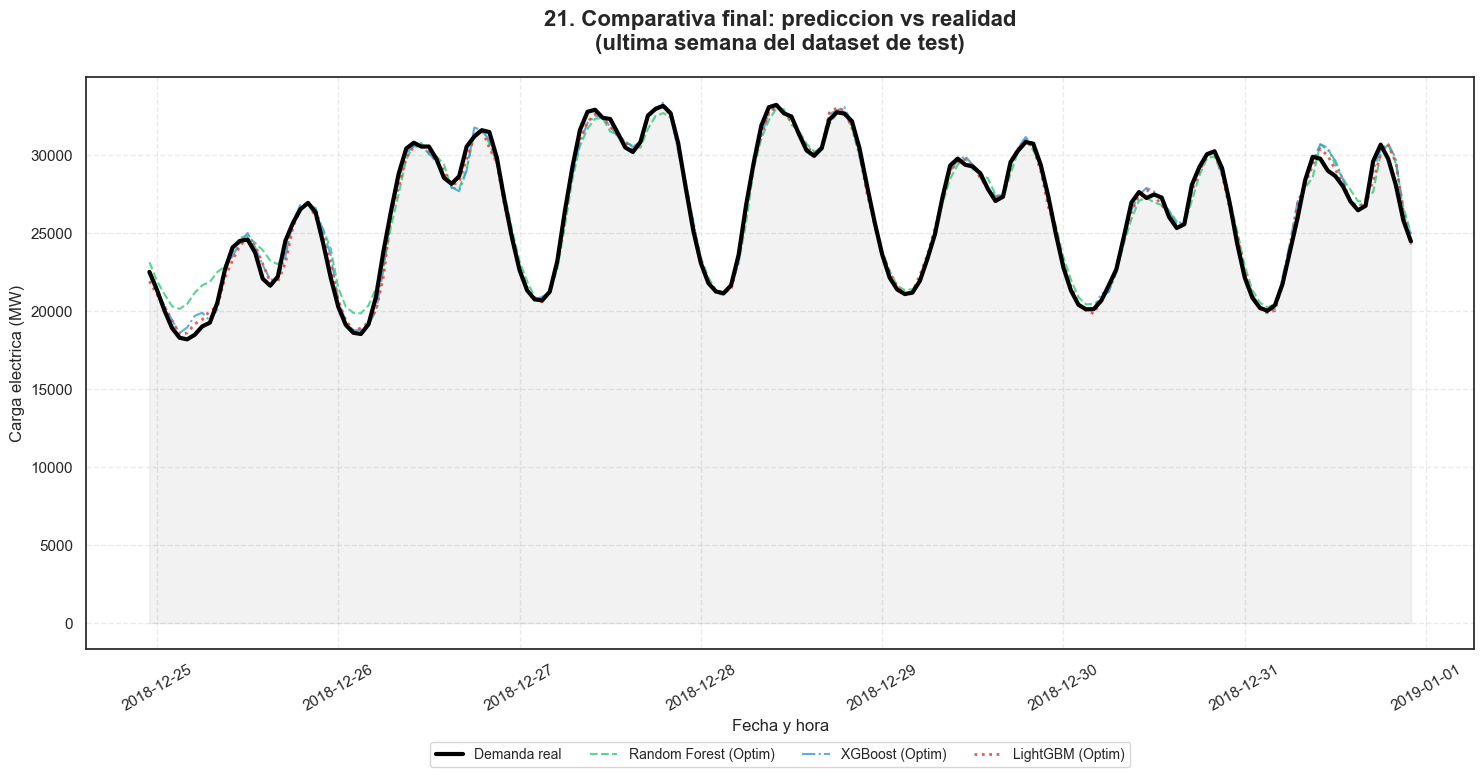

In [79]:
import matplotlib.pyplot as plt

# Configuramos el tamano y el estilo
plt.figure(figsize=(15, 8))

# 1. Definimos el rango (ultima semana: 168 horas)
last_hours = y_test.index[-168:]

# 2. Graficamos la realidad
plt.plot(last_hours, y_test.iloc[-168:], label='Demanda real', color='black', linewidth=3, zorder=5)

# 3. Graficamos los 3 modelos optimizados
plt.plot(last_hours, y_pred_opt[-168:], label='Random Forest (Optim)', color='#2ecc71', linestyle='--', alpha=0.8, linewidth=1.5)
plt.plot(last_hours, y_pred_xgb_opt[-168:], label='XGBoost (Optim)', color='#3498db', linestyle='-.', alpha=0.8, linewidth=1.5)
plt.plot(last_hours, y_pred_lgb_opt[-168:], label='LightGBM (Optim)', color='#e74c3c', linestyle=':', alpha=0.9, linewidth=2)
if 'y_tso' in globals() and y_tso is not None:
    plt.plot(last_hours, y_tso.loc[last_hours], label='Forecast TSO', color='gray', alpha=0.5)

# 4. Configuracion estetica
plt.title('21. Comparativa final: prediccion vs realidad\n(ultima semana del dataset de test)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha y hora', fontsize=12)
plt.ylabel('Carga electrica (MW)', fontsize=12)
plt.fill_between(last_hours, y_test.iloc[-168:], alpha=0.05, color='black')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=10, frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---

##   22. Conclusiones y Hallazgos Clave

###   Responsable: Todos


### Analisis de Resultados y Justificacion Tecnica

La lectura final debe apoyarse en `df_comparativa` y en las visualizaciones de las secciones 20 y 21, no en cifras fijas escritas a mano. Con este flujo, las conclusiones robustas son:

1. **Seleccion del mejor modelo:** el candidato a produccion debe ser el que obtenga el menor error en el conjunto de test (`MAE`, `RMSE` y `MAPE`).
2. **Factores determinantes:** en este tipo de problema suelen destacar los lags de demanda, la temperatura y las variables temporales, algo que puede verificarse con las graficas de importancia.
3. **Validez temporal del experimento:** la evaluacion se hace con corte cronologico y el early stopping usa validacion interna, evitando contaminar el test final.

### Nota
Si `total load forecast` no esta disponible en `df_ml`, la comparativa frente al TSO queda fuera del alcance de esta version del notebook y no conviene extraer conclusiones sobre ese benchmark.

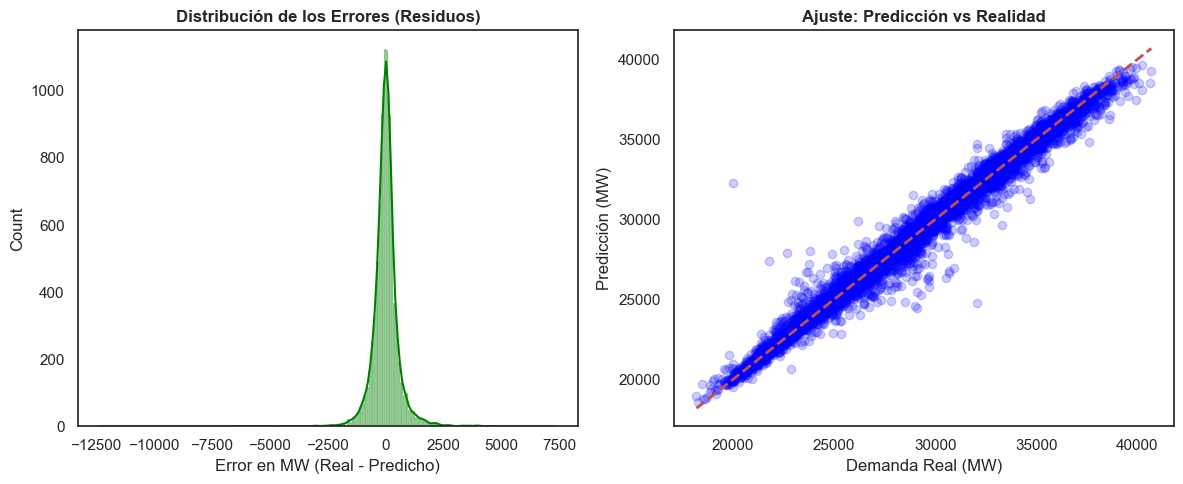

✅ ANÁLISIS TÉCNICO: La distribución de errores centrada en 0 indica que el modelo no tiene sesgo.
El modelo XGBoost es capaz de seguir la diagonal perfecta (línea roja) con una varianza mínima,
confirmando su robustez para ser desplegado en un entorno de producción real.


In [80]:
import seaborn as sns

# Calculamos los errores (Residuos) del mejor modelo
residuos = y_test - y_pred_xgb_opt

plt.figure(figsize=(12, 5))

# Gráfico 1: Distribución del Error
plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, color='green')
plt.title('Distribución de los Errores (Residuos)', fontsize=12, fontweight='bold')
plt.xlabel('Error en MW (Real - Predicho)')

# Gráfico 2: Error vs Valor Real (Para ver si fallamos más en consumo alto o bajo)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb_opt, alpha=0.2, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Ajuste: Predicción vs Realidad', fontsize=12, fontweight='bold')
plt.xlabel('Demanda Real (MW)')
plt.ylabel('Predicción (MW)')

plt.tight_layout()
plt.show()

# Párrafo final explicativo
print(f"✅ ANÁLISIS TÉCNICO: La distribución de errores centrada en 0 indica que el modelo no tiene sesgo.")
print(f"El modelo XGBoost es capaz de seguir la diagonal perfecta (línea roja) con una varianza mínima,")
print(f"confirmando su robustez para ser desplegado en un entorno de producción real.")

---

##   22. Conclusiones y Hallazgos Clave

###   Responsable: Todos


### Analisis de Resultados y Justificacion Tecnica

La lectura final debe apoyarse en `df_comparativa` y en las visualizaciones de las secciones 20 y 21, no en cifras fijas escritas a mano. Con este flujo, las conclusiones robustas son:

1. **Seleccion del mejor modelo:** el candidato a produccion debe ser el que obtenga el menor error en el conjunto de test (`MAE`, `RMSE` y `MAPE`).
2. **Factores determinantes:** en este tipo de problema suelen destacar los lags de demanda, la temperatura y las variables temporales, algo que puede verificarse con las graficas de importancia.
3. **Validez temporal del experimento:** la evaluacion se hace con corte cronologico y el early stopping usa validacion interna, evitando contaminar el test final.

### Nota
Si `total load forecast` no esta disponible en `df_ml`, la comparativa frente al TSO queda fuera del alcance de esta version del notebook y no conviene extraer conclusiones sobre ese benchmark.